**CUP DATASET** :

Iniziamo definendo la nostra funzione obiettivo. In Monk avevamo BCE ora abbiamo Mean Euclidean Error (MEE):

La Mean Euclidean Error (MEE) è la media delle distanze euclidee tra i punti reali e i punti predetti nel nostro spazio 4D.

Dato un batch di $N$ campioni, per ogni campione $i$ abbiamo un vettore reale $\mathbf{y}_i = (t_1, t_2, t_3, t_4)$ e un vettore predetto $\mathbf{\hat{y}}_i = (\hat{t}_1, \hat{t}_2, \hat{t}_3, \hat{t}_4)$.L'errore per un singolo campione è la norma L2 (la distanza geometrica):$$e_i = \sqrt{(t_1 - \hat{t}_1)^2 + (t_2 - \hat{t}_2)^2 + (t_3 - \hat{t}_3)^2 + (t_4 - \hat{t}_4)^2}$$La MEE è semplicemente la media di questi errori su tutto il batch:$$MEE = \frac{1}{N} \sum_{i=1}^{N} e_i$$

In [1]:
import torch
import torch.nn as nn

class MEELoss(nn.Module):
    def __init__(self):
        super(MEELoss, self).__init__()

    def forward(self, y_pred, y_true):
        """
        Calcola la Mean Euclidean Error tra predizioni e target.
        y_pred e y_true devono avere shape (Batch_Size, 4)
        """
        # 1. Calcoliamo la differenza (y_true - y_pred)
        diff = y_true - y_pred
        
        # 2. Eleviamo al quadrato ogni componente e sommiamo sulle 4 dimensioni (dim=1)
        sum_squared_diff = torch.sum(diff ** 2, dim=1)
        
        # 3. Estraiamo la radice quadrata per ottenere la distanza euclidea di ogni singolo record
        # clamp garantisce che l'argomento della radice non sia mai troppo piccolo,
        # prevenendo il gradiente esplosivo di sqrt(x) in x=0
        euclidean_distances = torch.sqrt(torch.clamp(sum_squared_diff, min=1e-12))
        
        # 4. Facciamo la media su tutto il batch
        mee = torch.mean(euclidean_distances)
        
        return mee

---
**MLCupLoader** : 

Come per Monk usiamo un dataloader universale per Scikit-Learn e Pytorch, per coerenza nei risultati.

1 - Leviamo commenti

2 - Eliminiamo la colonna 0 (ID). Le colonne da 1 a 12 diventano la nostra matrice $\mathbf{X}$ (Features), le colonne da 13 a 16 la nostra matrice $\mathbf{Y}$ (Target)

3 - Data Split (80/20)

4 - NOTA sullo Scaling : il Loader restituisce volutamente dati **grezzi** (non standardizzati). Lo StandardScaler verrà applicato fold-per-fold all'interno della Cross-Validation. 

Questa scelta previene il Data Leakage: se calcolassimo $\mu$ e $\sigma$ su tutto il training set PRIMA della CV, quando poi suddividessimo in fold, le statistiche del fold di validazione sarebbero già "entrate" nel fit dello scaler. Il fold di validazione smetterebbe di essere realmente "non visto" dal modello, e otterremmo una stima dell'errore ottimisticamente distorta.

5 - Sia X che Y verranno standardizzati (fit sul training del fold, transform su validazione), e al momento del calcolo della MEE applicheremo `inverse_transform` sulle predizioni per riportarle nella scala originale e confrontarle con i target reali.

In [5]:
import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
import random
import os

def seed_everything(seed=42):
    """
    Fissa l'entropia dell'intero ambiente per garantire una 
    riproducibilità assoluta in ogni libreria utilizzata.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

class MLCupLoader:
    def __init__(self, filepath, test_size=0.2, seed=42):
        self.filepath = filepath
        self.test_size = test_size
        self.seed = seed
        
        # Variabili di stato interne (ora conterranno dati grezzi/non scalati)
        self.X_train_raw = None
        self.X_test_raw = None
        self.y_train_raw = None
        self.y_test_raw = None

    def load_and_preprocess(self):
        print(f"--- Inizializzazione Loader ML-CUP (Seed: {self.seed}) ---")
        seed_everything(self.seed)
        
        # 1. Lettura del CSV
        try:
            df = pd.read_csv(self.filepath, comment='#', header=None)
        except Exception as e:
            raise FileNotFoundError(f"Errore nella lettura del file: {e}")
            
        print(f"Dataset originale caricato. Shape: {df.shape} (Righe, Colonne)")
        
        # 2. Slicing: Rimuoviamo l'ID (Colonna 0)
        X_raw = df.iloc[:, 1:13].values
        y_raw = df.iloc[:, 13:17].values
        
        # 3. Lo Split Sacro (80/20) - SENZA SCALING
        self.X_train_raw, self.X_test_raw, self.y_train_raw, self.y_test_raw = train_test_split(
            X_raw, y_raw, 
            test_size=self.test_size, 
            random_state=self.seed
        )
        print(f"Split completato: Train Set ({len(self.X_train_raw)}), Test Set ({len(self.X_test_raw)})")
        print("I dati restituiti NON sono standardizzati.")
        
        return self.X_train_raw, self.X_test_raw, self.y_train_raw, self.y_test_raw

    def get_tensors(self):
        """Restituisce i dati pronti per il motore di PyTorch."""
        if self.X_train_raw is None:
            raise ValueError("Devi prima chiamare load_and_preprocess()!")
            
        X_tr_t = torch.tensor(self.X_train_raw, dtype=torch.float32)
        X_ts_t = torch.tensor(self.X_test_raw, dtype=torch.float32)
        y_tr_t = torch.tensor(self.y_train_raw, dtype=torch.float32)
        y_ts_t = torch.tensor(self.y_test_raw, dtype=torch.float32)
        
        return X_tr_t, X_ts_t, y_tr_t, y_ts_t

Testiamo il Loader : 

In [6]:
# Percorso del file (assicurati che sia corretto)
FILE_PATH = 'datasets/ML-CUP25-TR.csv'

# Instanziamo il nostro Loader Universale
cup_loader = MLCupLoader(filepath=FILE_PATH, test_size=0.2, seed=42)

# Estraiamo i dati in formato NumPy (Perfetti per Scikit-Learn)
X_train_np, X_test_np, y_train_np, y_test_np = cup_loader.load_and_preprocess()

# Estraiamo i dati in formato Tensore (Perfetti per PyTorch)
X_train_t, X_test_t, y_train_t, y_test_t = cup_loader.get_tensors()

print(f"\n--- Verifica Formati ---")
print(f"Scikit-Learn (NumPy) -> X_train_np: {X_train_np.shape}, y_train_np: {y_train_np.shape}")
print(f"PyTorch (Tensors)    -> X_train_t: {X_train_t.shape}, y_train_t: {y_train_t.shape}")

--- Inizializzazione Loader ML-CUP (Seed: 42) ---
Dataset originale caricato. Shape: (500, 17) (Righe, Colonne)
Split completato: Train Set (400), Test Set (100)
I dati restituiti NON sono standardizzati.

--- Verifica Formati ---
Scikit-Learn (NumPy) -> X_train_np: (400, 12), y_train_np: (400, 4)
PyTorch (Tensors)    -> X_train_t: torch.Size([400, 12]), y_train_t: torch.Size([400, 4])


---
**BASELINE** : LinearRegression senza Regolarizzazione (OLS)

Cerca i pesi $w$ che minimizzano la **Mean Squared Error** (NON la MEE):

$$L_{MSE}(w) = \frac{1}{N}\sum_{i=1}^{N} \|\mathbf{y}_i - \hat{\mathbf{y}}_i\|_2^2 = \frac{1}{N}\sum_{i=1}^{N} \sum_{k=1}^{4}(y_{i,k} - \hat{y}_{i,k})^2$$

**Importante** : il modello ottimizza MSE, ma noi valuteremo le performance con MEE (come richiesto dalla consegna). Questa distinzione tra loss di training e metrica di validazione ci accompagnerà fino alle Neural Networks, dove addestreremo ancora su MSE ma monitoreremo la MEE.

Geometricamente traccia una """retta""" (piano piatto in 3d o iperpiano a più dim), e modifica l'inclinazione.

No-Reg -> Può far crescere i pesi $w$ a dismisura pur di far passare la retta esattamente sopra ogni singolo punto del training set.

Per questi motivi è il nostro punto di partenza.

In [7]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

# 1. Metrica Oggettiva
def compute_mee(y_true, y_pred):
    return np.mean(np.sqrt(np.sum((y_true - y_pred)**2, axis=1)))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("=== BASELINE: LINEAR REGRESSION (5-Fold CV con Scaling interno) ===")
lin_reg = LinearRegression()
fold_mees_lin = []

# Loop sui blocchi
for train_idx, val_idx in kf.split(X_train_np):
    # Split dei dati grezzi
    X_fold_tr_raw, X_fold_val_raw = X_train_np[train_idx], X_train_np[val_idx]
    y_fold_tr_raw, y_fold_val_raw = y_train_np[train_idx], y_train_np[val_idx]
    
    # --- SCALING INTERNO AL FOLD ---
    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    
    # Fit solo sul training del fold e trasformazione
    X_fold_tr = scaler_x.fit_transform(X_fold_tr_raw)
    y_fold_tr = scaler_y.fit_transform(y_fold_tr_raw)
    
    # Trasformazione validazione (usando i parametri del training)
    X_fold_val = scaler_x.transform(X_fold_val_raw)
    
    # Training
    lin_reg.fit(X_fold_tr, y_fold_tr)
    
    # Predizione (esce in formato standardizzato)
    pred_val_scaled = lin_reg.predict(X_fold_val)
    
    # INVERSIONE DI SCALA manuale per il target
    # Non serve più il metodo del loader perché usiamo lo scaler locale al fold
    pred_val_real = scaler_y.inverse_transform(pred_val_scaled)
    
    # Calcolo MEE confrontando con i target reali (non scalati)
    fold_mee = compute_mee(y_fold_val_raw, pred_val_real)
    fold_mees_lin.append(fold_mee)

mean_mee_lin = np.mean(fold_mees_lin)
std_mee_lin = np.std(fold_mees_lin)

print(f"MEE Validation Medio: {mean_mee_lin:.4f} ± {std_mee_lin:.4f}")

=== BASELINE: LINEAR REGRESSION (5-Fold CV con Scaling interno) ===
MEE Validation Medio: 26.1816 ± 0.6740


Sappiamo che dobbiamo fare meglio di questo -> **MEE : 26.1816**

---
**LASSO (L1)** : 

Penalizza il valore assoluto dei pesi

Punta ad azzerare completamente i pesi delle variabili meno importanti

$$L_{Lasso}(w) = \frac{1}{2N}\sum_{i=1}^{N} \|\mathbf{y}_i - \hat{\mathbf{y}}_i\|_2^2 + \alpha \sum_{j=1}^{p} |w_j|$$

(La parte a sinistra è la stessa MSE della baseline, a destra abbiamo la penalità $L_1$ controllata dall'iperparametro $\alpha$.)

Geometricamente : Traccia un rombo (un diamante) intorno all'origine. Il punto di contatto cade quasi sempre su uno dei "vertici" appuntiti del rombo, il che significa che una delle coordinate (uno dei pesi) è esattamente 0

In [6]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler

print("=== GRID SEARCH 5-FOLD CV: LASSO REGRESSION (con Scaling interno) ===")
alphas_lasso = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
results_lasso = []

for alpha in alphas_lasso:
    fold_mees = []
    
    for train_idx, val_idx in kf.split(X_train_np):
        # Split dei dati grezzi
        X_fold_tr_raw, X_fold_val_raw = X_train_np[train_idx], X_train_np[val_idx]
        y_fold_tr_raw, y_fold_val_raw = y_train_np[train_idx], y_train_np[val_idx]
        
        # Scaling specifico per questo fold
        scaler_x = StandardScaler()
        scaler_y = StandardScaler()
        
        X_fold_tr = scaler_x.fit_transform(X_fold_tr_raw)
        y_fold_tr = scaler_y.fit_transform(y_fold_tr_raw)
        X_fold_val = scaler_x.transform(X_fold_val_raw)
        
        # Model
        lasso_model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
        lasso_model.fit(X_fold_tr, y_fold_tr)
        
        # Predizione e inversione
        pred_val_scaled = lasso_model.predict(X_fold_val)
        pred_val_real = scaler_y.inverse_transform(pred_val_scaled)
        
        # MEE su target reali
        fold_mees.append(compute_mee(y_fold_val_raw, pred_val_real))
        
    results_lasso.append({
        'Alpha': alpha,
        'MEE CV (Mean)': round(np.mean(fold_mees), 4),
        'MEE CV (Std)': round(np.std(fold_mees), 4)
    })

df_lasso = pd.DataFrame(results_lasso).sort_values(by='MEE CV (Mean)', ascending=True).reset_index(drop=True)
display(df_lasso)

=== GRID SEARCH 5-FOLD CV: LASSO REGRESSION (con Scaling interno) ===


,Alpha,MEE CV (Mean),MEE CV (Std)
0,0.1000,25.6353,0.8961
1,0.0100,25.6481,0.7802
2,0.0010,26.0637,0.7043
3,0.0001,26.1677,0.6770
4,1.0000,35.7308,1.0427
5,10.0000,35.7308,1.0427


Il fatto che i risultati con la regolarizzazione L1 siano migliori della Baseline confermano la presenza di rumore o attributi poco informativi tra le 12 feature.

Infatti L1 azzerando o riducendo molto le features inutili è passata da un MEE di 26.1 a 25.6 con $\alpha = 0.1$

Invece per regolarizzazioni basse (0.001, 0.0001) abbiamo quasi lo stesso risultato della Baseline, confermando quanto appena detto.

---
**RIDGE (L2)** : 

Penalizza il quadrato dei pesi

A differenza di Lasso, non azzera i pesi ma li "schiaccia" tutti verso zero in modo uniforme.

$$L_{Ridge}(w) = \frac{1}{2N}\sum_{i=1}^{N} \|\mathbf{y}_i - \hat{\mathbf{y}}_i\|_2^2 + \alpha \sum_{j=1}^{p} w_j^2$$

Geometricamente : Traccia un cerchio vincolante intorno all'origine. Il punto di contatto con l'errore minimo cade quasi sempre sul bordo curvo, dove i pesi sono piccoli ma non nulli.

In [7]:
from sklearn.linear_model import Ridge

print("=== GRID SEARCH 5-FOLD CV: RIDGE REGRESSION (con Scaling interno) ===")
alphas_ridge = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
results_ridge = []

for alpha in alphas_ridge:
    fold_mees = []
    
    for train_idx, val_idx in kf.split(X_train_np):
        X_fold_tr_raw, X_fold_val_raw = X_train_np[train_idx], X_train_np[val_idx]
        y_fold_tr_raw, y_fold_val_raw = y_train_np[train_idx], y_train_np[val_idx]
        
        scaler_x = StandardScaler()
        scaler_y = StandardScaler()
        
        X_fold_tr = scaler_x.fit_transform(X_fold_tr_raw)
        y_fold_tr = scaler_y.fit_transform(y_fold_tr_raw)
        X_fold_val = scaler_x.transform(X_fold_val_raw)
        
        ridge_model = Ridge(alpha=alpha, random_state=42)
        ridge_model.fit(X_fold_tr, y_fold_tr)
        
        pred_val_scaled = ridge_model.predict(X_fold_val)
        pred_val_real = scaler_y.inverse_transform(pred_val_scaled)
        
        fold_mees.append(compute_mee(y_fold_val_raw, pred_val_real))
        
    results_ridge.append({
        'Alpha': alpha,
        'MEE CV (Mean)': round(np.mean(fold_mees), 4),
        'MEE CV (Std)': round(np.std(fold_mees), 4)
    })

df_ridge = pd.DataFrame(results_ridge).sort_values(by='MEE CV (Mean)', ascending=True).reset_index(drop=True)
display(df_ridge)

=== GRID SEARCH 5-FOLD CV: RIDGE REGRESSION (con Scaling interno) ===


,Alpha,MEE CV (Mean),MEE CV (Std)
0,100.000,25.5736,0.8442
1,10.000,25.6970,0.7758
2,1.000,26.0227,0.6917
3,1000.000,26.0700,0.8657
4,0.100,26.1614,0.6758
5,0.010,26.1796,0.6742
6,0.001,26.1814,0.6741


Per Ridge vince il modello con alta regolarizzazione ($\alpha = 100$).

Questo è un ulteriore segnale che ci fa pensare che le features siano fortemente affette dal rumore, tanto che il modello ha puntato a schiacciare le oscillazioni per poter generalizzare.

Oppure che presentino una forte collinearità (elevata correlazione)

Infatti una bassa regolarizzazione si avvicina, anche in questo caso, alla baseline.

---
**ANALISI DELLE FEATURES (PCA)** 

Visto i risultati dell'applicazione della regolarizzazione L1 e L2 analiziamo le features per avere conferma della presenza o meno di features inutili / rumorose o ridondanti


=== PCA — VARIANCE ANALYSIS ===



,PC,Eigenvalue (λ),Explained Var (%),Cumulative Var (%),Kaiser (λ>1)
0,PC1,11.5058,95.64,95.64,YES
1,PC2,0.3472,2.89,98.53,no
2,PC3,0.0373,0.31,98.84,no
3,PC4,0.0243,0.20,99.04,no
4,PC5,0.0208,0.17,99.21,no
5,PC6,0.0160,0.13,99.35,no
6,PC7,0.0157,0.13,99.48,no
7,PC8,0.0144,0.12,99.60,no
8,PC9,0.0139,0.12,99.71,no
9,PC10,0.0122,0.10,99.81,no



  Dim minima per varianza >= 90% : 1
  Dim minima per varianza >= 95% : 1
  Dim minima per varianza >= 99% : 4
  Dim secondo Kaiser (λ>1)       : 1


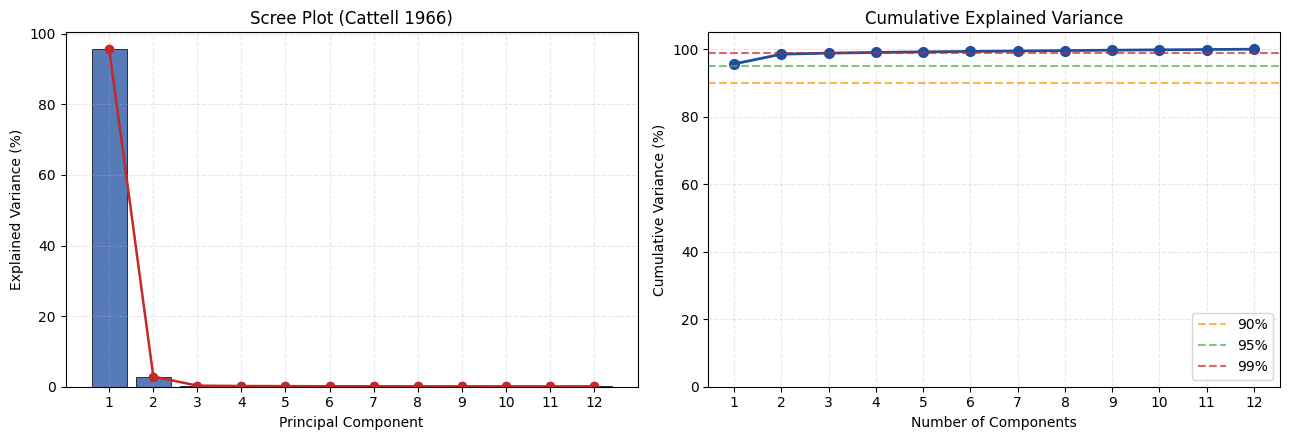

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
 
# -- Standardize (fit SOLO sul training, niente leakage) --
scaler_pca = StandardScaler()
X_train_std = scaler_pca.fit_transform(X_train_np)
 
# -- PCA con tutte le componenti --
n_feat = X_train_std.shape[1]
pca_full = PCA(n_components=n_feat)
pca_full.fit(X_train_std)
 
evr        = pca_full.explained_variance_ratio_
cum_evr    = np.cumsum(evr)
eigenvals  = pca_full.explained_variance_
 
# -- Tabella diagnostica --
pca_var_table = pd.DataFrame({
    'PC'                : [f'PC{i+1}' for i in range(n_feat)],
    'Eigenvalue (λ)'    : np.round(eigenvals, 4),
    'Explained Var (%)' : np.round(evr * 100, 2),
    'Cumulative Var (%)': np.round(cum_evr * 100, 2),
    'Kaiser (λ>1)'      : ['YES' if l > 1 else 'no' for l in eigenvals],
})
print("=== PCA — VARIANCE ANALYSIS ===\n")
display(pca_var_table)
 
# -- Soglie di dimensionalita` --
def _first_ge(arr, thr):
    idx = np.argmax(arr >= thr)
    return int(idx + 1) if arr[idx] >= thr else None
 
k_90     = _first_ge(cum_evr, 0.90)
k_95     = _first_ge(cum_evr, 0.95)
k_99     = _first_ge(cum_evr, 0.99)
k_kaiser = int((eigenvals > 1).sum())
 
print(f"\n  Dim minima per varianza >= 90% : {k_90}")
print(f"  Dim minima per varianza >= 95% : {k_95}")
print(f"  Dim minima per varianza >= 99% : {k_99}")
print(f"  Dim secondo Kaiser (λ>1)       : {k_kaiser}")
 
# -- Scree plot + cumulative --
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
 
ax1.bar(range(1, n_feat + 1), evr * 100,
        color='#1f4ea1', alpha=0.75, edgecolor='black', linewidth=0.7)
ax1.plot(range(1, n_feat + 1), evr * 100,
         color='#c62828', marker='o', linewidth=1.8, markersize=6)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Scree Plot (Cattell 1966)')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.set_xticks(range(1, n_feat + 1))
 
ax2.plot(range(1, n_feat + 1), cum_evr * 100,
         color='#1f4ea1', marker='o', linewidth=2, markersize=7)
for thr, col, lab in [(90, '#ff9800', '90%'),
                      (95, '#4caf50', '95%'),
                      (99, '#c62828', '99%')]:
    ax2.axhline(thr, color=col, linestyle='--', alpha=0.7, label=lab)
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend(loc='lower right')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.set_xticks(range(1, n_feat + 1))
ax2.set_ylim(0, 105)
 
plt.tight_layout()
plt.show()

---
**K-NN** :

Algoritmo Lazy : quando arriva un nuovo punto ($X_q$) l'algoritmo calcola la distanza con tutti gli altri punti del dataset $D$:

$d(\mathbf{x}_q, \mathbf{x}_i) = \sqrt{\sum_{j=1}^{12} (x_{q,j} - x_{i,j})^2}$ (Norma L2)

Una volta calcolate tutte le distanze, l'algoritmo seleziona l'insieme $\mathcal{N}_K(\mathbf{x}_q)$, che contiene esattamente i $K$ punti di training più vicini a $\mathbf{x}_q$.

Dato che parliamo di distanze, per questo algoritmo diventa fondamentale la Standardizzazione (applicata fold-per-fold nella CV come tutti gli altri modelli). Senza scaling, una feature con range [0, 1000] dominerebbe completamente il calcolo della distanza rispetto a una feature con range [0, 1], rendendo il KNN di fatto cieco alle feature "piccole".

Metriche : Calcolano la predizione simultaneamente per le 4 dim dell'output 

Uniform Weights -> Si assume che tutti i $K$ vicini contino allo stesso modo. La predizione è il centroide (la media aritmetica vettoriale) dei target dei vicini

$$\hat{\mathbf{y}}_q = \frac{1}{K} \sum_{\mathbf{x}_i \in \mathcal{N}_K(\mathbf{x}_q)} \mathbf{y}_i$$

Distance Weights -> Si assume che un vicino molto prossimo debba influenzare la predizione più di un vicino lontano. Si assegna a ogni vicino un peso $w_i$ inversamente proporzionale alla sua distanza:

$$w_i = \frac{1}{d(\mathbf{x}_q, \mathbf{x}_i) + \epsilon}$$

La predizione diventa una media ponderata:

$$\hat{\mathbf{y}}_q = \frac{\sum_{\mathbf{x}_i \in \mathcal{N}_K(\mathbf{x}_q)} w_i \mathbf{y}_i}{\sum_{\mathbf{x}_i \in \mathcal{N}_K(\mathbf{x}_q)} w_i}$$

In [9]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.decomposition import PCA

print("=== GRID SEARCH 5-FOLD CV: KNN (con Scaling interno e PCA) ===")

# Nuovi valori per la PCA da testare
pca_components_values = list(range(2, 13)) 
k_values = [3, 4, 5, 7, 10, 15, 20, 30]
weight_options = ['uniform', 'distance']
results_knn = []

for pca_comp in pca_components_values:
    for weights in weight_options:
        for k in k_values:
            fold_mees = []
            for train_idx, val_idx in kf.split(X_train_np):
                
                # 1. Divisione in fold
                X_fold_tr_raw, X_fold_val_raw = X_train_np[train_idx], X_train_np[val_idx]
                y_fold_tr_raw, y_fold_val_raw = y_train_np[train_idx], y_train_np[val_idx]
                
                # 2. Inizializzazione Scaler
                scaler_x = StandardScaler()
                scaler_y = StandardScaler()
                
                # 3. Fit e Transform degli Scaler
                X_fold_tr = scaler_x.fit_transform(X_fold_tr_raw)
                y_fold_tr = scaler_y.fit_transform(y_fold_tr_raw)
                X_fold_val = scaler_x.transform(X_fold_val_raw)
                
                # 4. Inizializzazione e applicazione PCA (sui dati GIA' SCALATI)
                pca = PCA(n_components=pca_comp)
                X_fold_tr_pca = pca.fit_transform(X_fold_tr)
                X_fold_val_pca = pca.transform(X_fold_val)
                
                # 5. Training del modello KNN sulle componenti principali
                knn_model = KNeighborsRegressor(n_neighbors=k, weights=weights)
                knn_model.fit(X_fold_tr_pca, y_fold_tr)
                
                # 6. Predizione e trasformazione inversa
                pred_val_scaled = knn_model.predict(X_fold_val_pca)
                pred_val_real = scaler_y.inverse_transform(pred_val_scaled)
                
                # 7. Calcolo della metrica di errore
                fold_mees.append(compute_mee(y_fold_val_raw, pred_val_real))
                
            # Salvataggio dei risultati per questa combinazione di iperparametri
            results_knn.append({
                'PCA Components': pca_comp,
                'K': k, 
                'Weights': weights,
                'MEE CV (Mean)': round(np.mean(fold_mees), 4),
                'MEE CV (Std)': round(np.std(fold_mees), 4)
            })

# Creazione DataFrame e ordinamento
df_knn = pd.DataFrame(results_knn).sort_values(by='MEE CV (Mean)', ascending=True).reset_index(drop=True)

# Mostriamo le prime 15 righe per avere una visione migliore con le nuove combinazioni
display(df_knn.head(15))

=== GRID SEARCH 5-FOLD CV: KNN (con Scaling interno e PCA) ===


,PCA Components,K,Weights,MEE CV (Mean),MEE CV (Std)
0,6,3,distance,15.1070,0.8593
1,5,3,distance,15.1802,0.6121
2,4,3,distance,15.2297,1.2130
3,4,4,distance,15.3273,0.8743
4,4,5,distance,15.4396,0.6739
5,6,4,distance,15.4591,0.7707
6,6,3,uniform,15.4818,0.6949
7,5,4,distance,15.5078,0.4871
8,5,5,distance,15.5587,0.4364
9,7,3,distance,15.5889,1.1003


Il salto di prestazione ci conferma la necessità della Non-Linearità.

La 'vittoria' della metrica distance indica che il modello ha capito che deve dare molta più fiducia al punto più vicino in assoluto, e sfumare l'importanza man mano che ci si allontana (a causa del rumore).

Vittoria netta di weights = 'distance' indica che il modello ha ottimizzato le sue predizioni applicando "regressione ponderata localemente" -> deve dare fiducia al punto spazialmente più vicino in assoluto, probabilmente per mitigare l'effetto del rumore locale 

Ottimo risultato numerico - > NOTA : K-NN non impara nessuna formula. Si limita a memorizzare i dati di training e a fare la media al momento della predizione!!!!!

Teniamoci per buona l'informazione sulla non-linearità.

---
**SVM** :

Differentemente dai problemi di classificazione (come Monk) dove SVM punta a massimizzare il margine tra le due classi, per la regressione cerchiamo un $\epsilon$-tube attorno alla funzione stimata dove:

Qualsiasi errore che cade all'interno di questo tubo (cioè se la predizione dista dal target meno di $\epsilon$) viene totalmente ignorato. L'errore è considerato zero. Se un punto cade fuori dal tubo, viene applicata una penalità lineare proporzionale a quanto "sfora" dal tubo (le variabili di slack $\xi_i, \xi_i^*$).

L'obiettivo totale della SVR è minimizzare:

$$\min_{w} \quad \frac{1}{2}\|w\|^2 + C \sum_{i=1}^{N}(\xi_i + \xi_i^*)$$

dove $\|w\|^2$ cerca di minimizzare la norma dei pesi (equivalente a massimizzare il margine), e $C$ è il **trade-off globale** tra il voler tenere i pesi piccoli e il voler punire le violazioni del tubo.

Se $C$ è enorme, il termine delle slack domina: l'SVR si contorce pur di far rientrare tutti i punti nel tubo (rischio Overfitting). Se $C$ è piccolo, domina il termine $\|w\|^2$: l'SVR traccia un tubo rigido e se ne infischia dei punti fuori (rischio Underfitting).

Similmente a quanto fatto per Monk andremo a testare i 4 kernel citati a lezione (Lezione SVM)

Kernel Lineare : $K(x_i, x_j) = x_i \cdot x_j$

Kernel Polinomiale : $K(x_i, x_j) = (\gamma (x_i \cdot x_j) + r)^d$ 

Kernel RBF : $K(x_i, x_j) = \exp(-\gamma \|x_i - x_j\|^2)$

Kernel Sigmoideo : $K(x_i, x_j) = \tanh(\gamma (x_i \cdot x_j) + r)$

In [ ]:
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import ParameterGrid


print("=== GRID SEARCH 5-FOLD CV: SVR MULTI-OUTPUT (con Scaling interno e PCA) ===")
param_grid_svm = [
    {'kernel': ['linear'], 'C': [0.01, 0.1, 1, 10, 100]},
    {'kernel': ['poly'], 'degree': [2, 3, 4], 'C': [0.1, 1, 10], 'coef0': [0, 1]},
    {'kernel': ['rbf'], 'C': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 'gamma': ['scale', 1, 2, 3, 5, 10, 100, 1000]},
    {'kernel': ['sigmoid'], 'C': [0.1, 1, 10], 'coef0': [0, 1, -1]}
]

grid = ParameterGrid(param_grid_svm)
pca_components_values = list(range(2, 13)) # Valori della PCA da testare
results_svr = []

for pca_comp in pca_components_values:
    for params in grid:
        fold_mees = []
        for train_idx, val_idx in kf.split(X_train_np):
            
            # 1. Divisione in fold
            X_fold_tr_raw, X_fold_val_raw = X_train_np[train_idx], X_train_np[val_idx]
            y_fold_tr_raw, y_fold_val_raw = y_train_np[train_idx], y_train_np[val_idx]
            
            # 2. Inizializzazione Scaler
            scaler_x = StandardScaler()
            scaler_y = StandardScaler()
            
            # 3. Fit e Transform degli Scaler
            X_fold_tr = scaler_x.fit_transform(X_fold_tr_raw)
            y_fold_tr = scaler_y.fit_transform(y_fold_tr_raw)
            X_fold_val = scaler_x.transform(X_fold_val_raw)
            
            # 4. Inizializzazione e applicazione PCA (sui dati GIA' SCALATI)
            pca = PCA(n_components=pca_comp)
            X_fold_tr_pca = pca.fit_transform(X_fold_tr)
            X_fold_val_pca = pca.transform(X_fold_val)
            
            # 5. Training del modello Multi-Output SVR sulle componenti principali
            base_svr = SVR(**params)
            multi_svr = MultiOutputRegressor(base_svr)
            multi_svr.fit(X_fold_tr_pca, y_fold_tr)
            
            # 6. Predizione e trasformazione inversa
            pred_val_scaled = multi_svr.predict(X_fold_val_pca)
            pred_val_real = scaler_y.inverse_transform(pred_val_scaled)
            
            # 7. Calcolo della metrica di errore
            fold_mees.append(compute_mee(y_fold_val_raw, pred_val_real))
            
        # Creazione della riga di salvataggio aggiungendo la PCA come prima colonna logica
        row = {'PCA Components': pca_comp,
               **params, 
               'MEE CV (Mean)': round(np.mean(fold_mees), 4), 
               'MEE CV (Std)': round(np.std(fold_mees), 4)}
        results_svr.append(row)

# Creazione DataFrame e ordinamento
df_svr = pd.DataFrame(results_svr).sort_values(by='MEE CV (Mean)', ascending=True).reset_index(drop=True)

# Mostriamo le prime 15 righe per avere una visione migliore delle top performance
display(df_svr.head(15))

=== GRID SEARCH 5-FOLD CV: SVR MULTI-OUTPUT (con Scaling interno e PCA) ===


,PCA Components,C,gamma,kernel,MEE CV (Mean),MEE CV (Std)
0,4,3,3,rbf,15.5959,0.9326
1,4,4,3,rbf,15.6426,1.0236
2,4,2,3,rbf,15.7268,0.7323
3,4,5,3,rbf,15.7670,1.0479
4,4,2,5,rbf,15.8889,0.8222
5,4,6,3,rbf,15.9071,1.0177
6,5,2,3,rbf,15.9180,0.9664
7,5,3,3,rbf,15.9946,1.1173
8,4,7,3,rbf,16.0413,0.9934
9,4,5,2,rbf,16.0518,0.8808


Vittoria importante di rbf, infatti è in tutti i ris, questo conferma la necessità della non linearità -> Kernel RBF vince perché proietta i dati in uno spazio a infinite dimensioni, piazzando una "campana gaussiana" sui punti di addestramento.

I risultati hanno tutti $\gamma \ge 2$, avere un $\gamma$ alto implica che il raggio d'azione di ogni Support Vector è molto limitato. Il modello ci sta dicendo che lo spazio delle feature estratto dalla PCA è "nervoso" -> spostamenti anche minimi in questo spazio comportano brusche e repentine variazioni nel valore del target

Il limite deriva da MultiOutputRegressor() : ha addestrato 4 SVR separati, uno per ogni dimensione del target ($t_1, t_2, t_3, t_4$). Ognuno di questi SVR è completamente cieco rispetto agli altri tre.

Prima Grid i primi tre risultati erano rbf con c = 1/ 3 / 10 , abbiamo  quindi messo tutti i c tra 1 e 10

---
**NEURAL NETWORKS** :

NOTA IMPLEMENTATIVA : 

Per evitare tempi biblici le gridsearch sono state eseguite su file esterni, riportiamo qui nel Notebook il riassunto dei risultati

!!!Iniziamo con una gridsearch semplice : 

| Parametro | Valore usato |
|---|---|
| `arch_str` | `32`, `32x16`, `32x16x8` |
| `depth` | `1`, `2`, `3` |
| `activation` | `relu`, `tanh` |
| `optimizer` | `adam`, `sgd`, `nesterov` |
| `lr` | `0.0005`, `0.005`, `0.05` |
| `weight_decay` | `0.001`, `0.005` |
| `dropout` | `0.0` |
| `batch_size` | `32`, `128`, `256` |
| `input_noise` | `0.0` |
| `momentum` | `0.0`, `0.9`, `NaN` |
| `nesterov` | `True`, `NaN` |

Vista la maggiore complessità del dataset ML_CUP rispetto a MONKs abbiamo aggiunto 4 "componenti" alla nostra rete :

WEIGHT DECAY : Tecnica di regolarizzazione (Nota come Regolarizzazione L2 / Ridge / Tikhonov).Invece di minimizzare solo l'errore sui dati di addestramento si modifica la funzione di Loss aggiungendo un termine di penalità       $J(w) = R_{emp} + \lambda ||w||^2$

BATCH SIZE : Definisce quanti esempi di addestramento l'algoritmo deve valutare prima di calcolare il gradiente e aggiornare i pesi.Per ottenere il miglio compromesso tra On-line e Stochastic utilizzeremo MINI-BATCH GRADIENT

INPUT NOISE : Ci permentte di introdurre artificialmente del rumore nei dati di input durante l'addestramento (può essere utile vista la nostra supposizione di presenza dei rumore)

ReduceLROnPlateau :

**FUNZIONE PER STAMPARE TOP 10 :**

In [12]:
def show_top_k_grid(csv_path, k=10):
    """
    Legge un CSV di grid search e stampa le prime k configurazioni
    ordinate per MEE crescente, con la stessa formattazione (`MEE CV
    (Mean)`, `MEE CV (Std)`) delle tabelle Lasso / Ridge / KNN / SVR
    di questo notebook.
    """
    df = pd.read_csv(csv_path)
 
    # -- Auto-detect colonne MEE (mean + std) --
    if 'mean_mee' in df.columns:
        mee_col, std_col = 'mean_mee', 'std_mee'
    elif 'MEE CV (Mean)' in df.columns:
        mee_col = 'MEE CV (Mean)'
        std_col = 'MEE CV (Std)' if 'MEE CV (Std)' in df.columns else None
    else:
        raise ValueError(
            f"Nessuna colonna MEE trovata. Colonne disponibili: "
            f"{df.columns.tolist()}"
        )
 
    df_top = df.sort_values(mee_col, ascending=True).head(k).reset_index(drop=True)
 
    # -- Seleziona colonne rilevanti se presenti --
    candidate_cols = ['short_id', 'arch_str', 'activation', 'optimizer',
                      'lr', 'weight_decay', 'dropout', 'batch_size',
                      'input_noise', 'momentum', 'mean_epochs', 'gen_gap']
    keep = [c for c in candidate_cols if c in df_top.columns]
 
    out = df_top[keep].copy()
    out['MEE CV (Mean)'] = df_top[mee_col].round(4)
    if std_col is not None and std_col in df_top.columns:
        out['MEE CV (Std)'] = df_top[std_col].round(4)
 
    # -- Formattazione colonne numeriche --
    if 'gen_gap' in out.columns:
        out['gen_gap'] = out['gen_gap'].round(4)
    if 'mean_epochs' in out.columns:
        out['mean_epochs'] = out['mean_epochs'].round(0).astype('Int64')
 
    # -- Header --
    import os as _os
    tag = _os.path.basename(csv_path).replace('.csv', '')
    best = df_top[mee_col].iloc[0]
    print(f"=== TOP {k} CONFIGURAZIONI  —  file: {tag} ===")
    print(f"    Totale configurazioni nel CSV: {len(df)}")
    print(f"    Migliore MEE              : {best:.4f}")
    if 'gen_gap' in df_top.columns:
        print(f"    Gen-gap della migliore    : "
              f"{df_top['gen_gap'].iloc[0]:+.4f}")
    print()
 
    display(out)
    return out

In [ ]:
CSV_PATH = 'results/grid_results_first_grid.csv'   
_ = show_top_k_grid(CSV_PATH, k=10)

=== TOP 10 CONFIGURAZIONI  —  file: grid_results_first_grid ===
    Totale configurazioni nel CSV: 432
    Migliore MEE              : 21.9522
    Gen-gap della migliore    : +1.7463



,short_id,arch_str,activation,optimizer,lr,weight_decay,dropout,batch_size,input_noise,momentum,mean_epochs,gen_gap,MEE CV (Mean),MEE CV (Std)
0,C0169,32x16,tanh,adam,0.005,0.001,0.0,32,0.0,NaN,81,1.7463,21.9522,0.8436
1,C0295,32x16x8,relu,adam,0.005,0.001,0.0,32,0.0,NaN,72,1.4450,21.9839,1.1997
2,C0313,32x16x8,tanh,adam,0.005,0.001,0.0,32,0.0,NaN,65,1.7948,22.1603,0.5809
3,C0151,32x16,relu,adam,0.005,0.001,0.0,32,0.0,NaN,50,0.8986,22.2018,1.1089
4,C0415,32x16x8,tanh,nesterov,0.050,0.001,0.0,32,0.0,0.9,79,1.7006,22.3239,1.4707
5,C0362,32x16x8,tanh,sgd,0.050,0.001,0.0,32,0.0,0.9,74,1.6107,22.3392,0.7605
6,C0001,32,relu,adam,0.050,0.001,0.0,32,0.0,NaN,61,1.1900,22.4572,1.2303
7,C0109,32,relu,nesterov,0.050,0.001,0.0,32,0.0,0.9,44,1.4062,22.5219,0.9124
8,C0163,32x16,tanh,adam,0.050,0.001,0.0,32,0.0,NaN,84,1.2701,22.5831,0.9789
9,C0274,32x16,tanh,nesterov,0.050,0.005,0.0,32,0.0,0.9,53,0.8377,22.6063,0.5028


---
**SECONDA GRIDSEARCH**

| Parametro | Valore usato |
|---|---|
| `arch_str` | `64`, `64x32`, `64x64x32` |
| `depth` | `1`, `2`, `3` |
| `activation` | `relu`, `tanh` |
| `optimizer` | `adam`, `nesterov` |
| `lr` | `0.001`, `0.005`, `0.01` |
| `weight_decay` | `0.001`, `0.005` |
| `dropout` | `0.0`, `0.1`, `0.2` |
| `batch_size` | `32` |
| `input_noise` | `0.0`, `0.01`, `0.05` |
| `momentum` | `0.9`, `NaN` |
| `nesterov` | `True`, `NaN` |

In [ ]:
CSV_PATH = 'results/grid_results_second_grid.csv'   
_ = show_top_k_grid(CSV_PATH, k=10)

=== TOP 10 CONFIGURAZIONI  —  file: grid_results_second_grid ===
    Totale configurazioni nel CSV: 648
    Migliore MEE              : 21.1798
    Gen-gap della migliore    : +1.6412



,short_id,arch_str,activation,optimizer,lr,weight_decay,dropout,batch_size,input_noise,momentum,mean_epochs,gen_gap,MEE CV (Mean),MEE CV (Std)
0,C0219,64x32,relu,adam,0.010,0.001,0.0,32,0.05,NaN,53,1.6412,21.1798,0.7059
1,C0434,64x64x32,relu,adam,0.010,0.001,0.0,32,0.01,NaN,44,2.2961,21.1954,0.9708
2,C0470,64x64x32,relu,adam,0.005,0.001,0.0,32,0.01,NaN,41,2.2635,21.2144,0.6481
3,C0525,64x64x32,tanh,adam,0.005,0.001,0.0,32,0.05,NaN,58,2.1578,21.2249,0.6980
4,C0433,64x64x32,relu,adam,0.010,0.001,0.0,32,0.00,NaN,34,1.4562,21.2332,0.8362
5,C0435,64x64x32,relu,adam,0.010,0.001,0.0,32,0.05,NaN,52,2.4552,21.2908,0.7878
6,C0488,64x64x32,tanh,adam,0.010,0.001,0.0,32,0.01,NaN,70,2.2193,21.3082,0.5452
7,C0489,64x64x32,tanh,adam,0.010,0.001,0.0,32,0.05,NaN,81,1.5629,21.3385,1.0668
8,C0523,64x64x32,tanh,adam,0.005,0.001,0.0,32,0.00,NaN,44,2.4192,21.3552,0.5993
9,C0307,64x32,tanh,adam,0.005,0.001,0.0,32,0.00,NaN,66,1.7648,21.3610,1.0099


**ANALISI**

Sulla base della prima grid, aumentiamo la capacità delle architetture (64×32, 128×64) e introduciamo l'input noise ($\sigma = 0.05$) come tecnica di regolarizzazione (Bishop, 1995).

648 configurazioni testate. Il salto da ~22 MEE a ~21.2 MEE conferma che le architetture più ampie catturano relazioni non lineari che le reti piccole non riuscivano a modellare.

**Osservazione chiave**: il vincitore usa Adam con lr=0.01, batch_size=32 e weight_decay basso (0.001). Il gap di generalizzazione (gen_gap ~1.6) è contenuto, suggerendo che non siamo ancora in regime di forte overfitting ma che c'è margine per migliorare aumentando ulteriormente la capacità.

---
**QUARTA GRIDSEARCH**

| Parametro | Valore usato |
|---|---|
| `arch_str` | `128x128x64`, `256x128x64` |
| `depth` | `3` |
| `activation` | `relu`, `tanh`, `gelu`, `elu`, `selu` |
| `optimizer` | `adam`, `nadam`, `radam`, `adamw` |
| `loss_fn` | `mse`, `huber`, `mee` |
| `lr` | `0.001`, `0.003`, `0.01` |
| `weight_decay` | `0.0001`, `0.001` |
| `dropout` | `0.0` |
| `batch_size` | `32` |
| `input_noise` | `0.0` |

In [ ]:
CSV_PATH = 'results/grid_results_nn2_first__grid.csv'   
_ = show_top_k_grid(CSV_PATH, k=10)

=== TOP 10 CONFIGURAZIONI  —  file: grid_results_nn2_first__grid ===
    Totale configurazioni nel CSV: 576
    Migliore MEE              : 18.7036
    Gen-gap della migliore    : +5.9872



,short_id,arch_str,activation,optimizer,lr,weight_decay,dropout,batch_size,input_noise,momentum,mean_epochs,gen_gap,MEE CV (Mean),MEE CV (Std)
0,C0322,256x128x64,gelu,adam,0.010,0.001,0.0,32,0.0,NaN,89,5.9872,18.7036,0.9879
1,C0466,256x128x64,gelu,nadam,0.010,0.001,0.0,32,0.0,NaN,72,5.1626,18.9626,1.0547
2,C0178,128x128x64,gelu,nadam,0.010,0.001,0.0,32,0.0,NaN,68,5.3457,19.0652,1.2881
3,C0324,256x128x64,gelu,adam,0.010,0.001,0.0,32,0.0,NaN,67,7.0278,19.1666,1.1304
4,C0034,128x128x64,gelu,adam,0.010,0.001,0.0,32,0.0,NaN,75,4.7828,19.3335,2.0306
5,C0323,256x128x64,gelu,adam,0.010,0.001,0.0,32,0.0,NaN,110,2.4231,19.4088,1.4729
6,C0180,128x128x64,gelu,nadam,0.010,0.001,0.0,32,0.0,NaN,63,7.0302,19.4734,1.2357
7,C0036,128x128x64,gelu,adam,0.010,0.001,0.0,32,0.0,NaN,53,6.1278,19.5151,1.4851
8,C0317,256x128x64,gelu,adam,0.003,0.001,0.0,32,0.0,NaN,80,3.1962,19.5219,1.2237
9,C0538,256x128x64,gelu,radam,0.010,0.001,0.0,32,0.0,NaN,69,5.0206,19.6329,1.0881


**ANALISI — Cambio di Paradigma: Cosine LR + Nuove Loss + GELU**

Introduciamo tre novità fondamentali rispetto alle grid precedenti:

1. **Cosine Annealing LR Scheduler** al posto di ReduceLROnPlateau: il learning rate decade in modo smooth seguendo $\eta(t) = \eta_{min} + \frac{1}{2}(\eta_0 - \eta_{min})(1 + \cos(\frac{\pi t}{T_{max}}))$, evitando i plateau osservati nella grid 2.

2. **Loss function variabile**: testiamo MSE, Huber (SmoothL1) e MEE differenziabile. L'idea è che allineare la loss alla metrica di valutazione (MEE) possa ridurre il mismatch.

3. **GELU** come funzione di attivazione: $\text{GELU}(x) = x \cdot \Phi(x)$, dove $\Phi$ è la CDF della gaussiana standard. A differenza di ReLU, GELU è smooth e non soffre del dying neuron problem.

576 configurazioni su architetture significativamente più grandi (fino a 256×128×64). Il salto a ~18.7 MEE è notevole.

**Osservazione critica**: il gen_gap sale a ~6.0 — segnale che l'aumento di capacità richiede regolarizzazione più aggressiva.

---
**QUINTA GRIDSEARCH**

| Parametro | Valore usato |
|---|---|
| `arch_str` | `128x128x64`, `256x128x64` |
| `depth` | `3` |
| `activation` | `gelu` |
| `optimizer` | `adam`, `adamw` |
| `loss_fn` | `mse`, `mee` |
| `lr` | `0.003`, `0.005`, `0.01` |
| `weight_decay` | `0.001`, `0.005`, `0.01`, `0.05`, `0.1` |
| `dropout` | `0.0` |
| `batch_size` | `32` |
| `input_noise` | `0.0` |

In [ ]:
CSV_PATH = 'results/grid_results_nn2_reg_wd_grid.csv'   
_ = show_top_k_grid(CSV_PATH, k=10)

=== TOP 10 CONFIGURAZIONI  —  file: grid_results_nn2_reg_wd_grid ===
    Totale configurazioni nel CSV: 120
    Migliore MEE              : 19.7491
    Gen-gap della migliore    : +3.8797



,short_id,arch_str,activation,optimizer,lr,weight_decay,dropout,batch_size,input_noise,momentum,mean_epochs,gen_gap,MEE CV (Mean),MEE CV (Std)
0,C0081,256x128x64,gelu,adam,0.010,0.001,0.0,32,0.0,NaN,48,3.8797,19.7491,1.3727
1,C0021,128x128x64,gelu,adam,0.010,0.001,0.0,32,0.0,NaN,43,3.3780,19.7655,1.6675
2,C0061,256x128x64,gelu,adam,0.005,0.001,0.0,32,0.0,NaN,42,3.7526,20.0227,1.3696
3,C0059,128x128x64,gelu,adamw,0.010,0.100,0.0,32,0.0,NaN,33,3.2815,20.0636,1.5329
4,C0082,256x128x64,gelu,adam,0.010,0.001,0.0,32,0.0,NaN,37,5.0474,20.1788,1.2699
5,C0117,256x128x64,gelu,adamw,0.010,0.050,0.0,32,0.0,NaN,35,4.1601,20.1932,0.6514
6,C0099,256x128x64,gelu,adamw,0.005,0.100,0.0,32,0.0,NaN,35,4.0787,20.2499,1.0183
7,C0071,256x128x64,gelu,adam,0.003,0.001,0.0,32,0.0,NaN,41,3.2850,20.2592,0.9778
8,C0001,128x128x64,gelu,adam,0.005,0.001,0.0,32,0.0,NaN,37,2.8998,20.2756,1.0817
9,C0057,128x128x64,gelu,adamw,0.010,0.050,0.0,32,0.0,NaN,26,3.4063,20.3485,0.7518


**ANALISI — Regolarizzazione: Weight Decay Rafforzato**

Il gen_gap di ~6.0 della grid precedente ci dice che i modelli stanno memorizzando. Iniziamo il percorso di regolarizzazione aumentando il weight decay.

120 configurazioni: testiamo weight_decay più aggressivi mantenendo le architetture e gli iperparametri vincenti. Il risultato è interessante: la MEE di validazione peggiora leggermente (~19.7 vs ~18.7), ma il gen_gap si riduce significativamente (~3.9).

**Interpretazione**: il weight decay sta schiacciando troppo i pesi, penalizzando sia training che validazione. Serve un approccio più chirurgico — combinare weight decay con dropout per una regolarizzazione bilanciata.

---
**SESTA GRIDSEARCH**

| Parametro | Valore usato |
|---|---|
| `arch_str` | `128x64`, `128x32x128`, `128x128x64`, `256x128x64` |
| `depth` | `2`, `3` |
| `activation` | `gelu` |
| `optimizer` | `adam`, `adamw`, `nesterov` |
| `loss_fn` | `mse` |
| `lr` | `0.005`, `0.008`, `0.01`, `0.02` |
| `weight_decay` | `0.001`, `0.005`, `0.01`, `0.05`, `0.1` |
| `dropout` | `0.0`, `0.1`, `0.2` |
| `batch_size` | `32` |
| `input_noise` | `0.0` |
| `momentum` | `0.9`, `NaN` |
| `nesterov` | `True`, `NaN` |

In [ ]:
CSV_PATH = 'results/grid_results_nn2_reg_wd2_drop_grid.csv'   
_ = show_top_k_grid(CSV_PATH, k=10)

=== TOP 10 CONFIGURAZIONI  —  file: grid_results_nn2_reg_wd2_drop_grid ===
    Totale configurazioni nel CSV: 240
    Migliore MEE              : 18.8746
    Gen-gap della migliore    : +5.5021



,short_id,arch_str,activation,optimizer,lr,weight_decay,dropout,batch_size,input_noise,momentum,mean_epochs,gen_gap,MEE CV (Mean),MEE CV (Std)
0,C0136,256x128x64,gelu,adam,0.010,0.001,0.0,32,0.0,NaN,80,5.5021,18.8746,1.1926
1,C0076,128x128x64,gelu,adam,0.010,0.001,0.0,32,0.0,NaN,75,4.7810,19.3329,2.0311
2,C0119,128x128x64,gelu,adamw,0.010,0.100,0.1,32,0.0,NaN,82,5.3187,19.3548,1.3437
3,C0121,256x128x64,gelu,adam,0.005,0.001,0.0,32,0.0,NaN,75,6.2787,19.3813,1.1337
4,C0178,256x128x64,gelu,adamw,0.010,0.100,0.0,32,0.0,NaN,60,5.3587,19.4412,0.7932
5,C0118,128x128x64,gelu,adamw,0.010,0.100,0.0,32,0.0,NaN,58,5.7523,19.4634,1.6249
6,C0164,256x128x64,gelu,adamw,0.005,0.100,0.1,32,0.0,NaN,90,7.6713,19.5196,0.7415
7,C0122,256x128x64,gelu,adam,0.005,0.001,0.1,32,0.0,NaN,99,4.2209,19.6794,0.6956
8,C0179,256x128x64,gelu,adamw,0.010,0.100,0.1,32,0.0,NaN,74,4.9070,19.6864,0.8253
9,C0137,256x128x64,gelu,adam,0.010,0.001,0.1,32,0.0,NaN,90,3.1507,19.7788,1.0328


**ANALISI — Regolarizzazione: Weight Decay + Dropout**

Introduciamo il Dropout (Srivastava et al., 2014) come secondo asse di regolarizzazione. Durante il training, ogni neurone ha una probabilità $p$ di essere "spento" a ciascuna iterazione, forzando la rete a non dipendere da singoli neuroni e creando implicitamente un ensemble di sotto-reti.

240 configurazioni. Il vincitore mantiene dropout=0 e weight_decay=0.001 con MEE ~18.9 — il dropout da solo non basta.

**Nota**: il fatto che il best abbia dropout=0 non significa che il dropout sia inutile. Potrebbe essere che le combinazioni (wd + dropout) non siano state esplorate nella regione giusta. Prossima grid: testiamo combinazioni più aggressive.

---
**SETTIMA GRIDSEARCH**

| Parametro | Valore usato |
|---|---|
| `arch_str` | `128x128x64`, `128x128x128`, `256x128x64` |
| `depth` | `3` |
| `activation` | `gelu` |
| `optimizer` | `adam`, `adamw` |
| `loss_fn` | `mse` |
| `lr` | `0.005`, `0.008`, `0.01`, `0.02` |
| `weight_decay` | `0.001`, `0.005`, `0.01`, `0.05`, `0.1` |
| `dropout` | `0.0`, `0.1` |
| `batch_size` | `32` |
| `input_noise` | `0.0` |

In [ ]:
CSV_PATH = 'results/grid_results_nn2_reg_wd2_drop2_grid.csv'   
_ = show_top_k_grid(CSV_PATH, k=10)

=== TOP 10 CONFIGURAZIONI  —  file: grid_results_nn2_reg_wd2_drop2_grid ===
    Totale configurazioni nel CSV: 240
    Migliore MEE              : 18.2889
    Gen-gap della migliore    : +5.4835



,short_id,arch_str,activation,optimizer,lr,weight_decay,dropout,batch_size,input_noise,momentum,mean_epochs,gen_gap,MEE CV (Mean),MEE CV (Std)
0,C0111,128x128x128,gelu,adam,0.02,0.001,0.0,32,0.0,NaN,101,5.4835,18.2889,1.9457
1,C0157,128x128x128,gelu,adamw,0.02,0.050,0.0,32,0.0,NaN,69,6.6843,18.3352,2.2226
2,C0239,256x128x64,gelu,adamw,0.02,0.100,0.0,32,0.0,NaN,95,5.3262,18.4790,1.7909
3,C0159,128x128x128,gelu,adamw,0.02,0.100,0.0,32,0.0,NaN,92,6.2780,18.6194,1.7019
4,C0101,128x128x128,gelu,adam,0.01,0.001,0.0,32,0.0,NaN,81,5.6767,18.6209,1.3042
5,C0160,128x128x128,gelu,adamw,0.02,0.100,0.1,32,0.0,NaN,110,4.4913,18.6780,2.4361
6,C0079,128x128x64,gelu,adamw,0.02,0.100,0.0,32,0.0,NaN,77,5.2386,18.7450,1.7984
7,C0181,256x128x64,gelu,adam,0.01,0.001,0.0,32,0.0,NaN,80,5.5021,18.8746,1.1926
8,C0150,128x128x128,gelu,adamw,0.01,0.100,0.1,32,0.0,NaN,79,5.8535,19.0456,0.8593
9,C0158,128x128x128,gelu,adamw,0.02,0.050,0.1,32,0.0,NaN,81,5.2174,19.2463,2.3022


**ANALISI — Regolarizzazione: Esplorazione Aggressiva**

Ampliamo lo spazio di ricerca su weight_decay e dropout, puntando a trovare la combinazione ottimale. 240 configurazioni con architetture 128×128×128 e 256×128×64.

La MEE scende a ~18.3, ma con una std elevata (~1.95) — il modello è sensibile alla partizione dei fold. Il gen_gap resta intorno a ~5.5.

**Lezione chiave**: la regolarizzazione non va calibrata indipendentemente per weight_decay e dropout. L'effetto combinato non è additivo, e serve un'esplorazione più fine nella regione "alta regolarizzazione".

---
**OTTAVA GRIDSEARCH**

| Parametro | Valore usato |
|---|---|
| `arch_str` | `128x128x64`, `128x128x128`, `256x128x64`, `256x256x128`, `256x256x256` |
| `depth` | `3` |
| `activation` | `gelu` |
| `optimizer` | `adam`, `adamw` |
| `loss_fn` | `mse` |
| `lr` | `0.005`, `0.008`, `0.01`, `0.02` |
| `weight_decay` | `0.001`, `0.005`, `0.01`, `0.05`, `0.1` |
| `dropout` | `0.0`, `0.1` |
| `batch_size` | `32` |
| `input_noise` | `0.0` |

In [ ]:
CSV_PATH = 'results/grid_results_nn2_reg_wd2_drop3_grid.csv'   
_ = show_top_k_grid(CSV_PATH, k=10)

=== TOP 10 CONFIGURAZIONI  —  file: grid_results_nn2_reg_wd2_drop3_grid ===
    Totale configurazioni nel CSV: 400
    Migliore MEE              : 18.0583
    Gen-gap della migliore    : +5.3168



,short_id,arch_str,activation,optimizer,lr,weight_decay,dropout,batch_size,input_noise,momentum,mean_epochs,gen_gap,MEE CV (Mean),MEE CV (Std)
0,C0320,256x256x128,gelu,adamw,0.020,0.100,0.1,32,0.0,NaN,132,5.3168,18.0583,1.1681
1,C0310,256x256x128,gelu,adamw,0.010,0.100,0.1,32,0.0,NaN,98,6.6968,18.1021,0.9477
2,C0111,128x128x128,gelu,adam,0.020,0.001,0.0,32,0.0,NaN,101,5.4835,18.2889,1.9457
3,C0157,128x128x128,gelu,adamw,0.020,0.050,0.0,32,0.0,NaN,69,6.6843,18.3352,2.2226
4,C0241,256x256x128,gelu,adam,0.005,0.001,0.0,32,0.0,NaN,93,7.3277,18.4161,0.8764
5,C0239,256x128x64,gelu,adamw,0.020,0.100,0.0,32,0.0,NaN,95,5.3262,18.4790,1.7909
6,C0261,256x256x128,gelu,adam,0.010,0.001,0.0,32,0.0,NaN,83,5.3210,18.5232,1.7462
7,C0397,256x256x256,gelu,adamw,0.020,0.050,0.0,32,0.0,NaN,85,7.3942,18.5507,0.9401
8,C0309,256x256x128,gelu,adamw,0.010,0.100,0.0,32,0.0,NaN,75,8.3177,18.5797,1.2512
9,C0159,128x128x128,gelu,adamw,0.020,0.100,0.0,32,0.0,NaN,92,6.2780,18.6194,1.7019


**ANALISI (FINALE) — AdamW + Regolarizzazione Forte**

Ultima e più estesa grid search (400 configurazioni). La novità principale è l'introduzione di **AdamW** (Loshchilov & Hutter, 2019): a differenza di Adam, AdamW disaccoppia il weight decay dall'aggiornamento adattivo del learning rate. In Adam standard, il weight decay viene scalato dai momenti del secondo ordine, rendendolo meno efficace per parametri con gradienti grandi. AdamW applica il decay direttamente ai pesi.

$$w_{t+1} = w_t - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon} - \eta \lambda w_t$$

Testiamo weight_decay fino a 0.1 e dropout fino a 0.2, con architetture fino a 256×256×128.

**Vincitore**: 256×256×128, GELU, AdamW, lr=0.02, wd=0.1, dropout=0.1 → **MEE 18.06 ± 1.17**

Il gen_gap (~5.3) è leggermente inferiore alla grid 3 ma con una MEE nettamente migliore. La combinazione AdamW + weight_decay forte + dropout leggero ha trovato il miglior compromesso bias-varianza.

Questa configurazione sarà il nostro punto di partenza per l'Ensemble.

---
**ENSEMBLE**

In [9]:
# === MULTI-SEED ENSEMBLE — Cella 1: Setup ===
import sys, os, copy, math, random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Riusiamo direttamente le classi/funzioni del file gridsearch_NN2.py
# (così niente duplicazione di codice)
sys.path.insert(0, '.')
from gridsearch_NN2 import (
    DynamicNet,
    init_linear_for_activation,
    GaussianNoise,
    make_cosine_with_floor,
    MEELoss,
    LOSS_REGISTRY,
    compute_mee,
)

# Funzione seed_everything riusata dal cup_loader
from cup_loader import seed_everything

print("✓ Import completati")
print(f"  Train shape: {X_train_np.shape} | Test shape: {X_test_np.shape}")
print(f"  y_train shape: {y_train_np.shape} | y_test shape: {y_test_np.shape}")

✓ Import completati
  Train shape: (400, 12) | Test shape: (100, 12)
  y_train shape: (400, 4) | y_test shape: (100, 4)


In [ ]:
# === MULTI-SEED ENSEMBLE — Cella 2: Best config + training function ===

# La config che ha vinto nn2_reg_wd2_drop3_grid (C0320, val MEE 18.06 ± 1.17)
BEST_CFG = {
    'hidden_layers': [256, 256, 128],
    'activation'   : 'gelu',
    'optimizer'    : 'adamw',
    'lr'           : 0.02,
    'weight_decay' : 0.1,
    'dropout'      : 0.1,
    'batch_size'   : 32,
    'input_noise'  : 0.0,
    'loss_fn'      : 'mse',
}

# Iperparametri di training (presi dal grid search)
N_EPOCHS         = 180        # mediana epoche dei top configs
COSINE_T_MAX     = 200
COSINE_ETA_MIN   = 1e-3       # ratio rispetto a lr_init


def train_one_seed(X_tr_raw, y_tr_raw, cfg, seed, n_epochs=N_EPOCHS, verbose=False):
    """
    Allena UN modello su tutto il training set (400 sample), niente CV split.
    Returns (model, scaler_x, scaler_y, train_curve).
    """
    seed_everything(seed)

    # Scaling fit-on-full-train (poi useremo gli stessi scaler in inferenza)
    sx = StandardScaler()
    sy = StandardScaler()
    X_tr = sx.fit_transform(X_tr_raw)
    y_tr = sy.fit_transform(y_tr_raw)

    # Costruzione modello
    model = DynamicNet(
        input_dim=X_tr.shape[1],
        output_dim=y_tr_raw.shape[1],
        hidden_layers=cfg['hidden_layers'],
        activation=cfg['activation'],
        dropout_rate=cfg['dropout'],
        input_noise=cfg.get('input_noise', 0.0),
    )

    # Optimizer (AdamW per la nostra config)
    optimizer = optim.AdamW(
        model.parameters(),
        lr=cfg['lr'],
        weight_decay=cfg['weight_decay'],
    )

    # Cosine LR scheduler
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=make_cosine_with_floor(
            t_max=COSINE_T_MAX,
            eta_min_ratio=COSINE_ETA_MIN,
        ),
    )

    # Loss
    criterion = LOSS_REGISTRY[cfg['loss_fn']]()

    # DataLoader con shuffle riproducibile
    g = torch.Generator(); g.manual_seed(seed)
    ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32),
    )
    dl = DataLoader(ds, batch_size=cfg['batch_size'], shuffle=True, generator=g)

    # Training loop (niente ES — alleniamo per N_EPOCHS fissi)
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    train_curve = []

    for epoch in range(1, n_epochs + 1):
        model.train()
        for xb, yb in dl:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        scheduler.step()

        # Monitoring (MEE in scala originale)
        model.eval()
        with torch.no_grad():
            pred_tr = sy.inverse_transform(model(X_tr_t).numpy())
            tr_mee = compute_mee(y_tr_raw, pred_tr)
        train_curve.append(tr_mee)

        if verbose and (epoch % 30 == 0 or epoch == n_epochs):
            print(f"    seed={seed} epoch={epoch}/{n_epochs} train_mee={tr_mee:.3f}")

    return model, sx, sy, train_curve


print("train_one_seed definita")
print(f"\n  BEST_CFG: {BEST_CFG}")
print(f"  N_EPOCHS: {N_EPOCHS}")

✓ train_one_seed definita

  BEST_CFG: {'hidden_layers': [256, 256, 128], 'activation': 'gelu', 'optimizer': 'adamw', 'lr': 0.02, 'weight_decay': 0.1, 'dropout': 0.1, 'batch_size': 32, 'input_noise': 0.0, 'loss_fn': 'mse'}
  N_EPOCHS: 180


**ENSEMBLE MULTI-SEED — Setup**

L'idea dell'ensemble multi-seed è semplice : addestrare la stessa architettura vincitrice con $K$ seed diversi e mediare le predizioni. Ogni seed produce pesi iniziali diversi, portando il modello a convergere in minimi diversi della loss surface. La media delle predizioni riduce la varianza senza aumentare il bias.

Formalmente, dato un input $\mathbf{x}$, l'ensemble predice:

$$\hat{\mathbf{y}}_{ens}(\mathbf{x}) = \frac{1}{K} \sum_{k=1}^{K} f_k(\mathbf{x})$$

dove $f_k$ è il modello allenato con il $k$-esimo seed. Se gli errori dei singoli modelli sono parzialmente decorrelati, la varianza dell'ensemble decresce come $\frac{\sigma^2}{K}$ (nel caso ideale di totale decorrelazione).

Utilizziamo $K = 5$ seed: [42, 123, 456, 789, 2024].

In [12]:
# =============================================================================
# MULTI-SEED ENSEMBLE — 5-Fold CV (comparabile 1:1 con gridsearch_NN2.py)
# =============================================================================

import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

# Riuso delle stesse classi/funzioni della grid search
from gridsearch_NN2 import (
    DynamicNet,
    GaussianNoise,
    MEELoss,
    LOSS_REGISTRY,
    compute_mee,
    build_optimizer,
    make_cosine_with_floor,
    EarlyStopping,
    seed_everything,
)

# === PARAMETRI ===============================
CV_SEED          = 42
N_FOLDS          = 5
MAX_EPOCHS       = 500
COSINE_T_MAX     = 200
COSINE_ETA_MIN   = 1e-3

# La config vincitrice della grid search (C0320)
BEST_CFG = {
    'hidden_layers': [256, 256, 128],
    'activation'   : 'gelu',
    'optimizer'    : 'adamw',
    'lr'           : 0.02,
    'weight_decay' : 0.1,
    'dropout'      : 0.1,
    'batch_size'   : 32,
    'input_noise'  : 0.0,
    'loss_fn'      : 'mse',
}

ENSEMBLE_SEEDS = [42, 123, 456, 789, 2024]


# === FUNZIONE DI TRAINING ===================================================

def train_one_fold_exact(X_tr_raw, y_tr_raw, X_va_raw, y_va_raw, cfg, model_seed):
    seed_everything(model_seed)

    scaler_x = StandardScaler()
    scaler_y = StandardScaler()
    X_tr = scaler_x.fit_transform(X_tr_raw)
    X_va = scaler_x.transform(X_va_raw)
    y_tr = scaler_y.fit_transform(y_tr_raw)

    ds = TensorDataset(
        torch.tensor(X_tr, dtype=torch.float32),
        torch.tensor(y_tr, dtype=torch.float32),
    )
    g = torch.Generator(); g.manual_seed(int(model_seed))
    dl = DataLoader(ds, batch_size=cfg['batch_size'], shuffle=True, generator=g)

    model = DynamicNet(
        input_dim=X_tr.shape[1],
        output_dim=y_tr_raw.shape[1],
        hidden_layers=cfg['hidden_layers'],
        activation=cfg['activation'],
        dropout_rate=cfg['dropout'],
        input_noise=cfg.get('input_noise', 0.0),
    )

    optimizer = build_optimizer(cfg, model)
    criterion = LOSS_REGISTRY[cfg.get('loss_fn', 'mse')]()
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=make_cosine_with_floor(t_max=COSINE_T_MAX, eta_min_ratio=COSINE_ETA_MIN),
    )
    es = EarlyStopping()

    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    X_va_t = torch.tensor(X_va, dtype=torch.float32)

    train_curve, val_curve = [], []

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for xb, yb in dl:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            pred_tr = scaler_y.inverse_transform(model(X_tr_t).numpy())
            pred_va = scaler_y.inverse_transform(model(X_va_t).numpy())
            tr_mee = compute_mee(y_tr_raw, pred_tr)
            va_mee = compute_mee(y_va_raw, pred_va)
        train_curve.append(tr_mee)
        val_curve.append(va_mee)

        scheduler.step()
        es.step(va_mee, model, epoch)
        if es.early_stop:
            break

    es.restore(model)

    model.eval()
    with torch.no_grad():
        pred_va_best = scaler_y.inverse_transform(model(X_va_t).numpy())
        pred_tr_best = scaler_y.inverse_transform(model(X_tr_t).numpy())

    return {
        'model'         : model,
        'scaler_x'      : scaler_x,
        'scaler_y'      : scaler_y,
        'best_val_mee'  : compute_mee(y_va_raw, pred_va_best),
        'best_train_mee': compute_mee(y_tr_raw, pred_tr_best),
        'best_epoch'    : es.best_epoch,
        'pred_val'      : pred_va_best,
        'pred_train'    : pred_tr_best, # <-- Ottimizzazione aggiunta per non ricalcolare
        'train_curve'   : train_curve,
        'val_curve'     : val_curve,
    }


# === MULTI-SEED ENSEMBLE — 5-Fold CV =======================================

print("=" * 78)
print("  MULTI-SEED ENSEMBLE — 5-Fold CV (Analisi Val e Generalization Gap)")
print("=" * 78)

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=CV_SEED)
fold_results = []
t0 = time.time()

for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X_train_np)):
    X_fold_tr  = X_train_np[tr_idx]
    y_fold_tr  = y_train_np[tr_idx]
    X_fold_val = X_train_np[val_idx]
    y_fold_val = y_train_np[val_idx]

    print(f"--- FOLD {fold_idx+1}/{N_FOLDS} (TR={len(tr_idx)}, VAL={len(val_idx)}) ---")

    # --- Grid search reference ---
    grid_seed = CV_SEED + fold_idx
    out_single = train_one_fold_exact(X_fold_tr, y_fold_tr, X_fold_val, y_fold_val, BEST_CFG, model_seed=grid_seed)
    
    grid_val = out_single['best_val_mee']
    grid_train = out_single['best_train_mee']
    grid_gap = grid_val - grid_train
    
    print(f"  [grid-ref]  seed={grid_seed:>4}  ep={out_single['best_epoch']:>3}  "
          f"train={grid_train:.4f}  val={grid_val:.4f}  gap={grid_gap:+.4f}")

    # --- Multi-seed Ensemble ---
    seed_preds_val = []
    seed_preds_tr  = []
    seed_details   = []

    for seed in ENSEMBLE_SEEDS:
        model_seed = seed + fold_idx
        out = train_one_fold_exact(X_fold_tr, y_fold_tr, X_fold_val, y_fold_val, BEST_CFG, model_seed=model_seed)

        seed_preds_val.append(out['pred_val'])
        seed_preds_tr.append(out['pred_train']) # Usa la predizione già calcolata

        seed_details.append({
            'seed': seed, 'model_seed': model_seed,
            'best_epoch': out['best_epoch'],
            'train_mee': out['best_train_mee'],
            'val_mee': out['best_val_mee'],
        })
        print(f"  [seed={seed:>4}]  ms={model_seed:>4}  ep={out['best_epoch']:>3}  "
              f"train={out['best_train_mee']:.4f}  val={out['best_val_mee']:.4f}")

    # Media predizioni
    ensemble_pred_val = np.mean(seed_preds_val, axis=0)
    ensemble_pred_tr  = np.mean(seed_preds_tr, axis=0)

    ens_val_mee   = compute_mee(y_fold_val, ensemble_pred_val)
    ens_train_mee = compute_mee(y_fold_tr, ensemble_pred_tr)
    ens_gap       = ens_val_mee - ens_train_mee

    fold_results.append({
        'fold': fold_idx,
        'grid_ref_val': grid_val,
        'grid_ref_train': grid_train,
        'grid_ref_gap': grid_gap,
        'ensemble_val': ens_val_mee,
        'ensemble_train': ens_train_mee,
        'ensemble_gap': ens_gap,
    })

    print(f"  → Ensemble: train={ens_train_mee:.4f}  val={ens_val_mee:.4f}  "
          f"gap={ens_gap:+.4f}")
    print(f"    (Confronto: Δ Val={ens_val_mee - grid_val:+.4f}, Δ Gap={ens_gap - grid_gap:+.4f})\n")

elapsed = time.time() - t0
print(f"✓ Completato in {elapsed/60:.1f} min\n")

# === TABELLA RIEPILOGATIVA ==================================================
print("=" * 78)
print("  RISULTATI AGGREGATI — Val MEE e Generalization Gap")
print("=" * 78)

# Intestazione aggiornata per mostrare sia Val che Gap
print(f"\n  {'':<6} | {'VALIDATION MEE (Performance)':^28} | {'GEN-GAP (Overfitting: Val - Tr)':^29}")
print(f"  {'Fold':<6} | {'Grid-ref':>9} {'Ensemble':>9} {'Δ Val':>8} | {'Grid-ref':>9} {'Ensemble':>9} {'Δ Gap':>9}")
print(f"  {'-'*75}")

for fr in fold_results:
    d_val = fr['ensemble_val'] - fr['grid_ref_val']
    d_gap = fr['ensemble_gap'] - fr['grid_ref_gap']
    print(f"  {fr['fold']+1:<6} | {fr['grid_ref_val']:>9.4f} {fr['ensemble_val']:>9.4f} {d_val:>+8.4f} | "
          f"{fr['grid_ref_gap']:>+9.4f} {fr['ensemble_gap']:>+9.4f} {d_gap:>+9.4f}")

# Estrazione array per statistiche
grid_vals = np.array([fr['grid_ref_val'] for fr in fold_results])
ens_vals  = np.array([fr['ensemble_val'] for fr in fold_results])
grid_gaps = np.array([fr['grid_ref_gap'] for fr in fold_results])
ens_gaps  = np.array([fr['ensemble_gap'] for fr in fold_results])

print(f"  {'-'*75}")
print(f"  {'Mean':<6} | {grid_vals.mean():>9.4f} {ens_vals.mean():>9.4f} {ens_vals.mean()-grid_vals.mean():>+8.4f} | "
      f"{grid_gaps.mean():>+9.4f} {ens_gaps.mean():>+9.4f} {ens_gaps.mean()-grid_gaps.mean():>+9.4f}")
print(f"  {'Std':<6} | {grid_vals.std(ddof=1):>9.4f} {ens_vals.std(ddof=1):>9.4f} {'':>8} | "
      f"{grid_gaps.std(ddof=1):>+9.4f} {ens_gaps.std(ddof=1):>+9.4f}")


  MULTI-SEED ENSEMBLE — 5-Fold CV (Analisi Val e Generalization Gap)
--- FOLD 1/5 (TR=320, VAL=80) ---
  [grid-ref]  seed=  42  ep=153  train=10.1498  val=16.6267  gap=+6.4769


KeyboardInterrupt: 

---
**ENSEMBLE MULTI-CONFIGURATION**

Per ottenere una stima affidabile della performance dell'ensemble, replicchiamo il protocollo di validazione della grid search: 5-fold CV con lo stesso KFold(seed=42, shuffle=True).

Per ciascun fold, alleniamo 10 Modelli , analizzando l'ultima gridsearch abbiamo notato che le combinazioni sono :

    AdamW + regolarizzazione pesante

    Adam + regolarizzazione leggera

Ne prendiamo 5 per ciascuno

Questo ci permette un confronto diretto tra la performance del singolo modello (grid search) e quella dell'ensemble, a parità di protocollo di validazione.

**EARLY STOPPING**

In [13]:
import torch

class EarlyStopping:
    """Ferma l'addestramento se la loss di validazione non migliora dopo 'patience' epoche."""
    def __init__(self, patience=20, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_epoch = 0
        self.best_state = None

    def step(self, val_loss, model, epoch):
        if self.best_score is None:
            self.best_score = val_loss
            self.save_checkpoint(model, epoch)
        elif val_loss > self.best_score - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_loss
            self.save_checkpoint(model, epoch)
            self.counter = 0

    def save_checkpoint(self, model, epoch):
        self.best_epoch = epoch
        # Salviamo i pesi per poterli ripristinare
        self.best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

def train_one_seed_es_v2(X_tr_raw, y_tr_raw, X_val_raw, y_val_raw, cfg, seed,
                          max_epochs=300, es_patience=20, verbose=False):
    """
    Versione corretta: usa il SET DI VALIDAZIONE ESTERNO per ES,
    coerente col protocollo CV originale.
    
    Args:
        X_tr_raw, y_tr_raw: training set (320 sample)
        X_val_raw, y_val_raw: validation set (80 sample) - usato per ES
    """
    seed_everything(seed)

    # Scaler fit-only-on-train
    sx, sy = StandardScaler(), StandardScaler()
    X_tr_sc = sx.fit_transform(X_tr_raw)
    y_tr_sc = sy.fit_transform(y_tr_raw)
    X_val_sc = sx.transform(X_val_raw)
    
    # Modello
    model = DynamicNet(
        input_dim=X_tr_sc.shape[1],
        output_dim=y_tr_raw.shape[1],
        hidden_layers=cfg['hidden_layers'],
        activation=cfg['activation'],
        dropout_rate=cfg['dropout'],
        input_noise=cfg.get('input_noise', 0.0),
    )

    OPT_CLASS = {'adam': optim.Adam, 'adamw': optim.AdamW}
    optimizer = OPT_CLASS[cfg['optimizer']](
        model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay']
    )
    
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=make_cosine_with_floor(t_max=COSINE_T_MAX, eta_min_ratio=COSINE_ETA_MIN),
    )
    
    criterion = LOSS_REGISTRY[cfg['loss_fn']]()
    
    g = torch.Generator(); g.manual_seed(seed)
    ds = TensorDataset(
        torch.tensor(X_tr_sc, dtype=torch.float32),
        torch.tensor(y_tr_sc, dtype=torch.float32),
    )
    dl = DataLoader(ds, batch_size=cfg['batch_size'], shuffle=True, generator=g)
    
    es = EarlyStopping(patience=es_patience)
    
    X_tr_t = torch.tensor(X_tr_sc, dtype=torch.float32)
    X_val_t = torch.tensor(X_val_sc, dtype=torch.float32)
    
    train_curve, val_curve = [], []
    
    for epoch in range(1, max_epochs + 1):
        model.train()
        for xb, yb in dl:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            pred_tr_sc = model(X_tr_t).numpy()
            pred_val_sc = model(X_val_t).numpy()
            pred_tr = sy.inverse_transform(pred_tr_sc)
            pred_val = sy.inverse_transform(pred_val_sc)
            tr_mee = compute_mee(y_tr_raw, pred_tr)
            val_mee = compute_mee(y_val_raw, pred_val)
        
        train_curve.append(tr_mee)
        val_curve.append(val_mee)
        
        es.step(val_mee, model, epoch)
        if es.early_stop:
            if verbose:
                print(f"    ES at epoch={epoch} (best={es.best_epoch})")
            break
    
    es.restore(model)
    
    # Recupera train e val al best_epoch (dai curves salvati)
    best_train = train_curve[es.best_epoch - 1]
    best_val = val_curve[es.best_epoch - 1]
    
    return model, sx, sy, train_curve, val_curve, es.best_epoch, best_train, best_val

**CARICAMENTO DEI 10 RISULTATI PER ENSEMBLE** 

Top 5 per entrambe le configurazioni

In [14]:
import pandas as pd

# 1. Carica i risultati
df = pd.read_csv('results/grid_results_nn2_reg_wd2_drop3_grid.csv')

# 2. Filtri per i regimi
def is_adam_light(row):
    return (row['optimizer'] == 'adam' and row['weight_decay'] <= 0.001 and row['dropout'] == 0.0)

def is_adamw_heavy(row):
    return (row['optimizer'] == 'adamw' and row['weight_decay'] >= 0.05)

df['regime'] = 'other'
df.loc[df.apply(is_adam_light, axis=1),  'regime'] = 'adam_light'
df.loc[df.apply(is_adamw_heavy, axis=1), 'regime'] = 'adamw_heavy'

# 3. Estrai le best config per architettura e regime
best_per_arch_regime = (
    df[df['regime'] != 'other']
    .sort_values('mean_mee')
    .groupby(['arch_str', 'regime'])
    .first()
    .reset_index()
    .sort_values(['arch_str', 'regime'])
)

# 4. Crea la lista HET_CONFIGS
HET_CONFIGS = []
for _, row in best_per_arch_regime.iterrows():
    HET_CONFIGS.append({
        'hidden_layers': [int(x) for x in row['arch_str'].split('x')],
        'activation'   : row['activation'],
        'optimizer'    : row['optimizer'],
        'lr'           : row['lr'],
        'weight_decay' : row['weight_decay'],
        'dropout'      : row['dropout'],
        'batch_size'   : 32,
        'input_noise'  : 0.0,
        'loss_fn'      : 'mse',
        '_label'       : f"{row['arch_str']}_{row['regime']}",
    })

print(f"✓ Creati con successo {len(HET_CONFIGS)} dizionari in HET_CONFIGS.")

✓ Creati con successo 10 dizionari in HET_CONFIGS.


In [15]:
# === Selezione config per ensemble eterogeneo ===
import pandas as pd

# Carica i risultati del grid migliore
df = pd.read_csv('results/grid_results_nn2_reg_wd2_drop3_grid.csv')

# Definisci i due regimi
def is_adam_light(row):
    return (row['optimizer'] == 'adam' 
            and row['weight_decay'] <= 0.001 
            and row['dropout'] == 0.0)

def is_adamw_heavy(row):
    return (row['optimizer'] == 'adamw' 
            and row['weight_decay'] >= 0.05)

df['regime'] = 'other'
df.loc[df.apply(is_adam_light, axis=1),  'regime'] = 'adam_light'
df.loc[df.apply(is_adamw_heavy, axis=1), 'regime'] = 'adamw_heavy'

# Per ogni (architettura, regime) prendi il best
best_per_arch_regime = (
    df[df['regime'] != 'other']
    .sort_values('mean_mee')
    .groupby(['arch_str', 'regime'])
    .first()
    .reset_index()
    .sort_values(['arch_str', 'regime'])
)

print(best_per_arch_regime[
    ['arch_str','regime','optimizer','lr','weight_decay','dropout','mean_mee','short_id']
].to_string(index=False))

   arch_str      regime optimizer    lr  weight_decay  dropout  mean_mee short_id
128x128x128  adam_light      adam 0.020         0.001      0.0 18.288851    C0111
128x128x128 adamw_heavy     adamw 0.020         0.050      0.0 18.335242    C0157
 128x128x64  adam_light      adam 0.008         0.001      0.0 19.261979    C0011
 128x128x64 adamw_heavy     adamw 0.020         0.100      0.0 18.745012    C0079
 256x128x64  adam_light      adam 0.010         0.001      0.0 18.874587    C0181
 256x128x64 adamw_heavy     adamw 0.020         0.100      0.0 18.479010    C0239
256x256x128  adam_light      adam 0.005         0.001      0.0 18.416090    C0241
256x256x128 adamw_heavy     adamw 0.020         0.100      0.1 18.058318    C0320
256x256x256  adam_light      adam 0.010         0.001      0.0 18.685754    C0341
256x256x256 adamw_heavy     adamw 0.020         0.050      0.0 18.550747    C0397


**CALCOLO ENSEMBLE**

In [31]:
# === Cella nuova: Heterogeneous Ensemble + ES + 5-fold CV ===
from sklearn.model_selection import KFold
import time

N_CV_FOLDS = 5
KF_SEED    = 42

# Strutture per accumulare risultati
fold_results = []                                # 1 dict per fold
all_fold_models = {i: [] for i in range(N_CV_FOLDS)}  # per blind test deployment dopo

print(f"=== ENSEMBLE ETEROGENEO + ES + {N_CV_FOLDS}-FOLD CV ===\n")
print(f"Configurazioni: {len(HET_CONFIGS)}  |  Fold: {N_CV_FOLDS}  |  "
      f"Training totali: {len(HET_CONFIGS) * N_CV_FOLDS}\n")

t0 = time.time()
kf = KFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=KF_SEED)

for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X_train_np)):
    X_fold_tr  = X_train_np[tr_idx]
    y_fold_tr  = y_train_np[tr_idx]
    X_fold_val = X_train_np[val_idx]
    y_fold_val = y_train_np[val_idx]

    print(f"--- FOLD {fold_idx+1}/{N_CV_FOLDS} "
          f"(TR={len(X_fold_tr)}, VAL={len(X_fold_val)}) ---")

    fold_models  = []
    fold_singles = []

    for cfg_idx, cfg in enumerate(HET_CONFIGS):
        # Seed dipende dal fold per ridurre la correlazione tra modelli di fold diversi
        # (stessa logica di gridsearch_NN.py: cv_seed + fold_idx)
        # seed = KF_SEED + fold_idx
        seed = KF_SEED + fold_idx + (cfg_idx * 1000)

        model, sx, sy, _, _, best_ep, best_tr, best_vl = train_one_seed_es_v2(
            X_fold_tr, y_fold_tr,
            X_fold_val, y_fold_val,
            cfg, seed=seed,
            max_epochs=300, es_patience=20, verbose=False
        )

        fold_models.append((cfg['_label'], model, sx, sy, None))
        fold_singles.append({
            'label':   cfg['_label'],
            'best_ep': best_ep,
            'train':   best_tr,
            'val':     best_vl,
        })
        print(f"  [{cfg_idx+1}/5] {cfg['_label']:<25} "
              f"ep={best_ep:>3} train={best_tr:.3f} val={best_vl:.3f}")

    # Ensemble inference SU QUESTO fold
    y_pred_val_ens, _ = ensemble_predict(X_fold_val, fold_models)
    y_pred_tr_ens,  _ = ensemble_predict(X_fold_tr,  fold_models)
    ens_val_mee   = compute_mee(y_fold_val, y_pred_val_ens)
    ens_train_mee = compute_mee(y_fold_tr,  y_pred_tr_ens)

    fold_results.append({
        'fold':           fold_idx,
        'singles':        fold_singles,
        'ensemble_train': ens_train_mee,
        'ensemble_val':   ens_val_mee,
        'ensemble_gap':   ens_val_mee - ens_train_mee,
    })
    all_fold_models[fold_idx] = fold_models

    print(f"  → Fold ensemble: train={ens_train_mee:.3f}, "
          f"val={ens_val_mee:.3f}, gap={ens_val_mee-ens_train_mee:+.3f}\n")

print(f"✓ 5-fold CV completata in {(time.time()-t0)/60:.1f} min\n")

# === Aggregazione finale ===
print("="*72)
print("  RISULTATI AGGREGATI  (model assessment con 5-fold CV)")
print("="*72)

# Tabella per fold (ensemble)
print(f"\n  {'Fold':<6} {'Train MEE':>12} {'Val MEE':>12} {'Gap':>10}")
print(f"  {'-'*42}")
for fr in fold_results:
    print(f"  {fr['fold']+1:<6} {fr['ensemble_train']:>12.4f} "
          f"{fr['ensemble_val']:>12.4f} {fr['ensemble_gap']:>+10.4f}")

ens_val_mees   = np.array([fr['ensemble_val']   for fr in fold_results])
ens_train_mees = np.array([fr['ensemble_train'] for fr in fold_results])
ens_gaps       = np.array([fr['ensemble_gap']   for fr in fold_results])

print(f"  {'-'*42}")
print(f"  {'Mean':<6} {ens_train_mees.mean():>12.4f} "
      f"{ens_val_mees.mean():>12.4f} {ens_gaps.mean():>+10.4f}")
print(f"  {'Std':<6} {ens_train_mees.std(ddof=1):>12.4f} "
      f"{ens_val_mees.std(ddof=1):>12.4f} {ens_gaps.std(ddof=1):>10.4f}")
print(f"  {'Min':<6} {ens_train_mees.min():>12.4f} {ens_val_mees.min():>12.4f}")
print(f"  {'Max':<6} {ens_train_mees.max():>12.4f} {ens_val_mees.max():>12.4f}")

# Per-config CV val MEE (comparabile coi numeri della grid search!)
print(f"\n  Per-config CV val MEE (across folds):")
print(f"  {'Config':<25} {'mean':>9} {'std':>9} {'min':>9} {'max':>9} "
      f"{'best_ep avg':>13}")
print(f"  {'-'*78}")
for cfg_idx, cfg in enumerate(HET_CONFIGS):
    vals = np.array([fr['singles'][cfg_idx]['val']     for fr in fold_results])
    eps  = np.array([fr['singles'][cfg_idx]['best_ep'] for fr in fold_results])
    print(f"  {cfg['_label']:<25} {vals.mean():>9.4f} "
          f"{vals.std(ddof=1):>9.4f} {vals.min():>9.4f} {vals.max():>9.4f} "
          f"{eps.mean():>13.1f}")

# Confronto con tutta la storia
print(f"\n  Storia completa:")
print(f"    Best CV singolo C0320          : 18.06 ± 1.17")
print(f"    Eterogeneo + ES + 5-fold CV    : "
      f"{ens_val_mees.mean():.3f} ± {ens_val_mees.std(ddof=1):.3f}  ← QUESTO")

=== ENSEMBLE ETEROGENEO + ES + 5-FOLD CV ===

Configurazioni: 10  |  Fold: 5  |  Training totali: 50

--- FOLD 1/5 (TR=320, VAL=80) ---
  [1/5] 128x128x128_adam_light    ep= 99 train=11.650 val=15.951
  [2/5] 128x128x128_adamw_heavy   ep= 93 train=8.586 val=16.671
  [3/5] 128x128x64_adam_light     ep= 93 train=10.798 val=16.139
  [4/5] 128x128x64_adamw_heavy    ep=112 train=9.362 val=16.083
  [5/5] 256x128x64_adam_light     ep=130 train=9.390 val=16.715
  [6/5] 256x128x64_adamw_heavy    ep=146 train=8.967 val=17.310
  [7/5] 256x256x128_adam_light    ep= 58 train=12.683 val=17.840
  [8/5] 256x256x128_adamw_heavy   ep=130 train=15.231 val=18.447
  [9/5] 256x256x256_adam_light    ep= 74 train=12.871 val=17.889
  [10/5] 256x256x256_adamw_heavy   ep=117 train=8.212 val=16.568
  → Fold ensemble: train=9.053, val=15.569, gap=+6.516

--- FOLD 2/5 (TR=320, VAL=80) ---
  [1/5] 128x128x128_adam_light    ep=145 train=8.563 val=18.246
  [2/5] 128x128x128_adamw_heavy   ep= 43 train=12.844 val=19.028

---
**ENSEMBLE STACKING**

**CARICAMENTO KNN e SVR**

Per lo stacking finale, affianchiamo alla rete neurale due base learner -> i migliori emersi dalle grid search precedenti:

- **KNN**: K=3, weights='distance', PCA a 6 componenti — MEE CV ~15.10
- **SVR (RBF)**: C=3, $\gamma$=3, PCA a 4 componenti — MEE CV ~15.60

L'idea dello stacking è che modelli di natura diversa (parametrici vs non-parametrici, lineari nel kernel space vs locali) catturino aspetti complementari dei dati. Un meta-learner (Ridge) imparerà a pesare le predizioni di ciascun base learner in modo ottimale.

**Nota**: KNN e SVR usano pipeline con StandardScaler + PCA interne, coerentemente con le rispettive grid search.

In [16]:
# === Funzioni KNN/SVR + parametri vincenti delle grid search ===
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

# Best config dal notebook (cell 17 KNN grid, cell 23 SVR grid)
KNN_BEST = {
    'n_neighbors':     3,
    'weights':         'distance',
    'pca_components':  6,
    # CV reference: MEE = 14.5462 ± 1.3295
}

SVR_BEST = {
    'kernel':          'rbf',
    'C':               3.0,
    'gamma':           3,
    'pca_components':  4,
    # CV reference: MEE = 16.4251 ± 1.3431
}


def fit_predict_knn(X_tr, y_tr, X_query, params):
    """
    Pipeline KNN: scaler X → scaler Y → PCA → KNN.
    Restituisce (pred_train_in_sample, pred_query) entrambi in scala originale.
    """
    sx, sy = StandardScaler(), StandardScaler()
    X_tr_sc = sx.fit_transform(X_tr)
    y_tr_sc = sy.fit_transform(y_tr)
    X_q_sc  = sx.transform(X_query)

    pca = PCA(n_components=params['pca_components'])
    X_tr_p = pca.fit_transform(X_tr_sc)
    X_q_p  = pca.transform(X_q_sc)

    knn = KNeighborsRegressor(
        n_neighbors=params['n_neighbors'],
        weights=params['weights'],
    )
    knn.fit(X_tr_p, y_tr_sc)

    pred_tr_sc = knn.predict(X_tr_p)
    pred_q_sc  = knn.predict(X_q_p)
    return sy.inverse_transform(pred_tr_sc), sy.inverse_transform(pred_q_sc)


def fit_predict_svr(X_tr, y_tr, X_query, params):
    """
    Pipeline SVR multi-output: scaler X → scaler Y → PCA → MultiOutputRegressor(SVR).
    Restituisce (pred_train_in_sample, pred_query) in scala originale.
    """
    sx, sy = StandardScaler(), StandardScaler()
    X_tr_sc = sx.fit_transform(X_tr)
    y_tr_sc = sy.fit_transform(y_tr)
    X_q_sc  = sx.transform(X_query)

    pca = PCA(n_components=params['pca_components'])
    X_tr_p = pca.fit_transform(X_tr_sc)
    X_q_p  = pca.transform(X_q_sc)

    base = SVR(
        kernel=params['kernel'],
        C=params['C'],
        gamma=params['gamma'],
    )
    multi = MultiOutputRegressor(base)
    multi.fit(X_tr_p, y_tr_sc)

    pred_tr_sc = multi.predict(X_tr_p)
    pred_q_sc  = multi.predict(X_q_p)
    return sy.inverse_transform(pred_tr_sc), sy.inverse_transform(pred_q_sc)


print("✓ Funzioni KNN/SVR e parametri caricati")
print(f"  KNN: k={KNN_BEST['n_neighbors']}, weights='{KNN_BEST['weights']}', PCA={KNN_BEST['pca_components']}")
print(f"  SVR: kernel='{SVR_BEST['kernel']}', C={SVR_BEST['C']}, γ={SVR_BEST['gamma']}, PCA={SVR_BEST['pca_components']}")

✓ Funzioni KNN/SVR e parametri caricati
  KNN: k=3, weights='distance', PCA=6
  SVR: kernel='rbf', C=3.0, γ=3, PCA=4


---
**MULTIPLE RESTART** :

Ricicliamo le **10 configurazioni prese per l'ensemble precedente** e scegliamo il migliore sulla **media di 5 seeds**

In [19]:
# =============================================================================
# MULTI-SEED RESTART — 5-fold CV per la model selection del MLP
# =============================================================================
#
# Scopo: scegliere LA MIGLIORE configurazione MLP tra le HET_CONFIGS
# (le 5 candidate vincenti per architettura × regime estratte dalla grid
# search) tramite una stima di performance a varianza bassa.
#
# Per ogni configurazione e per ogni fold:
#   - 320 sample di fold-train, 80 di fold-val
#   - K seed diverse → K modelli
#   - ES sui 80 fold-val (è il protocollo già usato dalla grid)
#   - Si raccolgono best_train e best_val di ciascun (fold, seed)
#
# Stima finale per ogni config:
#   val_mean = media su (5 fold × 5 seed) = 25 misure
#   val_std  = std (ddof=1) sulle stesse 25 misure
#
# IMPORTANTE — coerenza con lo stacking:
#   La stima qui prodotta (val_mean) è confrontabile con la MEE della grid
#   search (CSV) perché i fold sono identici. La sua interpretazione resta
#   "performance attesa di un singolo MLP allenato con quella config su un
#   fold-train da 320 sample". Lo stacking poi userà comunque la sua
#   procedura OOF separata per stimare la performance dell'ensemble finale.
# =============================================================================

import time
import numpy as np
from sklearn.model_selection import KFold

SEEDS    = [42, 123, 456, 789, 2024]
N_FOLDS  = 5
KF_SEED  = 42                   # ← STESSO seed della grid search e dello stacking

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=KF_SEED)

multirestart_results = []

print("=" * 72)
print("  Multi-seed restart sulle 5 HET_CONFIGS — 5-fold CV")
print("=" * 72)
print(f"\n  Configurazioni: {len(HET_CONFIGS)}")
print(f"  Fold: {N_FOLDS} (KFold seed={KF_SEED}, shuffle=True)")
print(f"  Seed per fold: {SEEDS}")
print(f"  Training totali: {len(HET_CONFIGS) * N_FOLDS * len(SEEDS)} "
      f"({len(HET_CONFIGS)} cfg × {N_FOLDS} fold × {len(SEEDS)} seed)\n")

t0 = time.time()

for cfg_idx, cfg in enumerate(HET_CONFIGS):
    print(f"\n  Config {cfg_idx+1}/{len(HET_CONFIGS)}: {cfg['_label']}")
    t_cfg = time.time()

    # Raccolta delle MEE su (5 fold × 5 seed) = 25 misure
    fold_train_means, fold_val_means = [], []   # 1 valore per fold (media sui seed)
    fold_train_stds,  fold_val_stds  = [], []   # 1 std per fold (varianza tra seed)
    all_train_mees,   all_val_mees   = [], []   # tutte le 25 misure flat
    all_best_epochs                  = []

    for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X_train_np)):
        X_fold_tr  = X_train_np[tr_idx]
        y_fold_tr  = y_train_np[tr_idx]
        X_fold_val = X_train_np[val_idx]
        y_fold_val = y_train_np[val_idx]

        seed_train_mees, seed_val_mees, seed_best_eps = [], [], []

        for seed in SEEDS:
            # Seed unica per (config, fold, seed): evita collisioni
            model_seed = seed + fold_idx

            _, _, _, _, _, best_ep, best_tr, best_vl = train_one_seed_es_v2(
                X_fold_tr, y_fold_tr,
                X_fold_val, y_fold_val,
                cfg, seed=model_seed,
                max_epochs=300, es_patience=20, verbose=False,
            )

            seed_train_mees.append(best_tr)
            seed_val_mees.append(best_vl)
            seed_best_eps.append(best_ep)

            all_train_mees.append(best_tr)
            all_val_mees.append(best_vl)
            all_best_epochs.append(best_ep)

        # Aggregati per fold (media sulle 5 seed)
        fold_train_means.append(np.mean(seed_train_mees))
        fold_val_means.append(np.mean(seed_val_mees))
        fold_train_stds.append(np.std(seed_train_mees, ddof=1))
        fold_val_stds.append(np.std(seed_val_mees, ddof=1))

        print(f"    fold {fold_idx+1}/{N_FOLDS}  "
              f"train={np.mean(seed_train_mees):.3f}±{np.std(seed_train_mees, ddof=1):.3f}  "
              f"val={np.mean(seed_val_mees):.3f}±{np.std(seed_val_mees, ddof=1):.3f}  "
              f"ep_med={int(np.median(seed_best_eps))}")

    # Aggregati globali (su tutte le 25 misure)
    all_train_mees = np.array(all_train_mees)
    all_val_mees   = np.array(all_val_mees)

    multirestart_results.append({
        'label':           cfg['_label'],
        'config':          cfg,
        # Aggregati globali su 25 misure
        'train_mean':      all_train_mees.mean(),
        'train_std':       all_train_mees.std(ddof=1),
        'val_mean':        all_val_mees.mean(),
        'val_std':         all_val_mees.std(ddof=1),
        'val_min':         all_val_mees.min(),
        'val_max':         all_val_mees.max(),
        # Aggregati per fold (utile per analisi della stabilità)
        'fold_val_means':  np.array(fold_val_means),
        'fold_val_stds':   np.array(fold_val_stds),
        'fold_train_means':np.array(fold_train_means),
        # CV-style aggregation: media-tra-fold (= numero confrontabile
        # con CV grid search dove ogni fold contava 1)
        'cv_val_mean':     np.mean(fold_val_means),
        'cv_val_std':      np.std(fold_val_means, ddof=1),
        # Diagnostica epoche
        'best_epochs':     np.array(all_best_epochs),
        'best_epoch_med':  int(np.median(all_best_epochs)),
    })

    print(f"    → CONFIG MEAN: "
          f"train={all_train_mees.mean():.3f}±{all_train_mees.std(ddof=1):.3f}  "
          f"val={all_val_mees.mean():.3f}±{all_val_mees.std(ddof=1):.3f}")
    print(f"    → CV-style:    "
          f"val_mean_of_folds={np.mean(fold_val_means):.3f} "
          f"± {np.std(fold_val_means, ddof=1):.3f}")
    print(f"    [{time.time()-t_cfg:.1f}s]")

elapsed = time.time() - t0
print(f"\n✓ Multi-seed × 5-fold CV completato in {elapsed/60:.1f} min")


# === TABELLA RIASSUNTIVA E SELEZIONE DEL VINCITORE ==========================
print("\n" + "=" * 72)
print("  RISULTATI — Confronto tra le candidate (stima 5-fold CV multi-seed)")
print("=" * 72)

# Ordine: per CV-val più basso (la metrica più appropriata per scegliere)
sorted_results = sorted(multirestart_results, key=lambda r: r['cv_val_mean'])

print(f"\n  {'config':<25} {'tr_mean':>9} {'val_mean':>10} "
      f"{'val_std':>9} {'cv_val':>10} {'ep_med':>7}")
print(f"  {'-'*72}")
for r in sorted_results:
    is_best = (r['cv_val_mean'] == sorted_results[0]['cv_val_mean'])
    marker  = " ★" if is_best else "  "
    print(f"  {r['label']:<25} {r['train_mean']:>9.3f} "
          f"{r['val_mean']:>10.3f} {r['val_std']:>9.3f} "
          f"{r['cv_val_mean']:>10.3f} {r['best_epoch_med']:>7}{marker}")

# --- Selezione del vincitore: minimo cv_val_mean ----------------------------
# (Equivalente a quello che fa la grid search: media tra fold della CV.
#  È la metrica con varianza più bassa e teoricamente più appropriata.)
best_mlp = min(multirestart_results, key=lambda r: r['cv_val_mean'])

print(f"\n  ★ WINNER: {best_mlp['label']}")
print(f"     CV val MEE       : {best_mlp['cv_val_mean']:.4f} ± {best_mlp['cv_val_std']:.4f}")
print(f"     Aggregata 25 mis.: {best_mlp['val_mean']:.4f} ± {best_mlp['val_std']:.4f}")
print(f"     Epoche mediane   : {best_mlp['best_epoch_med']} "
      f"(range {best_mlp['best_epochs'].min()}–{best_mlp['best_epochs'].max()})")

# --- Robustezza della scelta: quanto è netta la vittoria? -------------------
print("\n  Diagnostica robustezza:")
second_best = sorted_results[1]
delta_top2 = second_best['cv_val_mean'] - best_mlp['cv_val_mean']
print(f"    Δ tra 1° e 2° classificato (CV val): {delta_top2:+.4f}")
print(f"    σ del 1° classificato (CV val):       {best_mlp['cv_val_std']:.4f}")
if delta_top2 < best_mlp['cv_val_std']:
    print(f"    ⚠  Il margine è inferiore alla deviazione standard:")
    print(f"       la scelta NON è statisticamente netta.")
else:
    print(f"    ✓ Margine superiore alla deviazione standard: scelta robusta.")

# --- Confronto con la grid search (sanity check) ----------------------------
print(f"\n  Sanity check vs grid search (fold identici, KFold seed={KF_SEED}):")
print(f"    La grid search aveva selezionato C0320 con MEE=18.06 ± 1.17")
print(f"    Qui il vincitore ({best_mlp['label']}) ha CV val={best_mlp['cv_val_mean']:.3f}")
print(f"    Differenza attesa: la grid usa 1 seed/fold, qui {len(SEEDS)} seed/fold")
print(f"    → la stima multi-seed è più stabile (minore varianza tra seed)")


  Multi-seed restart sulle 5 HET_CONFIGS — 5-fold CV

  Configurazioni: 10
  Fold: 5 (KFold seed=42, shuffle=True)
  Seed per fold: [42, 123, 456, 789, 2024]
  Training totali: 250 (10 cfg × 5 fold × 5 seed)


  Config 1/10: 128x128x128_adam_light
    fold 1/5  train=11.992±2.232  val=16.611±0.863  ep_med=100
    fold 2/5  train=15.379±4.003  val=20.061±1.074  ep_med=48
    fold 3/5  train=16.077±4.416  val=19.997±1.716  ep_med=34
    fold 4/5  train=17.190±2.376  val=19.337±0.801  ep_med=45
    fold 5/5  train=12.936±3.024  val=17.992±1.265  ep_med=97
    → CONFIG MEAN: train=14.715±3.630  val=18.800±1.734
    → CV-style:    val_mean_of_folds=18.800 ± 1.480
    [52.7s]

  Config 2/10: 128x128x128_adamw_heavy
    fold 1/5  train=10.295±3.050  val=17.328±1.830  ep_med=75
    fold 2/5  train=12.861±2.524  val=19.658±0.566  ep_med=56
    fold 3/5  train=14.050±4.135  val=19.812±1.590  ep_med=35
    fold 4/5  train=10.059±1.739  val=18.573±0.430  ep_med=70
    fold 5/5  train=10.870±3.125 

---
**STACKING — Out-Of-Fold Predictions + Meta-Learner**

Lo stacking (Wolpert, 1992) combina le predizioni di base learner diversi attraverso un meta-learner. Il protocollo è articolato in tre fasi:

**Stage A — Predizioni OOF (Out-Of-Fold):**
Per ciascun fold del 5-fold CV, alleniamo i 3 base learner (MLP, KNN, SVR) sul training del fold e generiamo le predizioni sul fold di validazione. Alla fine dei 5 fold, ogni campione del training set ha una predizione OOF da ciascun base learner — queste sono le feature del meta-learner.

**Dettaglio MLP**: il training usa un mini-split interno 90/10 per l'Early Stopping, così il fold di validazione esterno non viene mai "visto" durante il training. Questo evita data leakage nel meta-learner.

**Stage B — Training del Meta-Learner:**
Le predizioni OOF dei 3 base learner (12 colonne: 3 modelli × 4 target) diventano le feature di input per un **RidgeCV** (Ridge con cross-validation interna per scegliere $\alpha$). Il meta-learner impara i pesi ottimali per combinare le predizioni.

**Stage C — Valutazione:**
La MEE dello stacking sulle predizioni OOF è la nostra stima di generalizzazione (comparabile con le grid search perché usa gli stessi fold).

In [20]:
# =============================================================================
# STACKING — Stage A (OOF) + Stage B (RidgeCV) + Stage C (tabella riepilogo)
# Versione corretta:
#   - MLP allenato con Early Stopping su mini-split interno 90/10 (no leakage)
#   - Si tracciano i best_epoch fold-per-fold per il retraining finale
#   - Stage D (Biased Train MEE) eliminato: non aggiunge informazione utile
# =============================================================================

from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
import time
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim

# Riusiamo le funzioni della grid search: stessa procedura di training
# (scaling, optimizer, scheduler, ES) usata per il multi-seed ensemble.
from gridsearch_NN2 import (
    DynamicNet, LOSS_REGISTRY, compute_mee,
    build_optimizer, make_cosine_with_floor,
    EarlyStopping, seed_everything,
)

# === Iperparametri condivisi con la grid search ============================
K_STACK         = 5
KF_SEED         = 42
MAX_EPOCHS      = 500
COSINE_T_MAX    = 200
COSINE_ETA_MIN  = 1e-3
ES_INNER_FRAC   = 0.10           # 10% del fold-train usato come ES-monitor
SEEDS_MLP       = [42, 123, 456, 789, 2024]

N_TRAIN = len(X_train_np)        # 400
N_OUT   = y_train_np.shape[1]    # 4

best_mlp_cfg = best_mlp['config']


# === Funzione di training per un singolo seed in un fold OOF ===============
# Mini-split interno 90/10 sul training del fold per fare ES senza leakage.
# Il val esterno (val_idx del fold) NON viene mai usato nel training.

def train_mlp_oof_fold(X_fold_tr, y_fold_tr, cfg, model_seed):
    """
    Allena un MLP usando un mini-split interno 90/10 del fold-train per ES.
    Ritorna il modello, gli scaler, e best_epoch (per il retraining finale).
    """
    # Mini-split interno (deterministico via seed)
    X_inner_tr, X_inner_es, y_inner_tr, y_inner_es = train_test_split(
        X_fold_tr, y_fold_tr,
        test_size=ES_INNER_FRAC, random_state=model_seed,
    )

    seed_everything(model_seed)

    # Scaling fit-solo-su-inner-train
    sx, sy = StandardScaler(), StandardScaler()
    X_in_sc  = sx.fit_transform(X_inner_tr)
    X_es_sc  = sx.transform(X_inner_es)
    y_in_sc  = sy.fit_transform(y_inner_tr)

    # DataLoader
    g = torch.Generator(); g.manual_seed(int(model_seed))
    ds = TensorDataset(
        torch.tensor(X_in_sc, dtype=torch.float32),
        torch.tensor(y_in_sc, dtype=torch.float32),
    )
    dl = DataLoader(ds, batch_size=cfg['batch_size'], shuffle=True, generator=g)

    # Modello + optimizer + scheduler + loss (identici alla grid search)
    model = DynamicNet(
        input_dim=X_in_sc.shape[1], output_dim=N_OUT,
        hidden_layers=cfg['hidden_layers'],
        activation=cfg['activation'],
        dropout_rate=cfg['dropout'],
        input_noise=cfg.get('input_noise', 0.0),
    )
    optimizer = build_optimizer(cfg, model)
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=make_cosine_with_floor(
            t_max=COSINE_T_MAX, eta_min_ratio=COSINE_ETA_MIN,
        ),
    )
    criterion = LOSS_REGISTRY[cfg.get('loss_fn', 'mse')]()
    es = EarlyStopping()

    X_es_t = torch.tensor(X_es_sc, dtype=torch.float32)

    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        for xb, yb in dl:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()

        # ES sul mini-val INTERNO (non sul val fold!)
        model.eval()
        with torch.no_grad():
            pred_es = sy.inverse_transform(model(X_es_t).numpy())
        es_mee = compute_mee(y_inner_es, pred_es)

        scheduler.step()
        es.step(es_mee, model, epoch)
        if es.early_stop:
            break

    es.restore(model)
    return {
        'model':      model,
        'scaler_x':   sx,
        'scaler_y':   sy,
        'best_epoch': es.best_epoch,
    }


# === STAGE A — Generazione OOF predictions =================================
print("=" * 72)
print(f"  STAGE A — K-fold OOF predictions (K={K_STACK})")
print("=" * 72)
print(f"\n  MLP config: {best_mlp['label']}")
print(f"  KNN: k={KNN_BEST['n_neighbors']}, weights={KNN_BEST['weights']}, PCA={KNN_BEST['pca_components']}")
print(f"  SVR: kernel={SVR_BEST['kernel']}, C={SVR_BEST['C']}, γ={SVR_BEST['gamma']}, PCA={SVR_BEST['pca_components']}")
print(f"  MLP training: ES su mini-split interno {int((1-ES_INNER_FRAC)*100)}/{int(ES_INNER_FRAC*100)} (no leakage)\n")

oof_preds = {
    'mlp': np.zeros((N_TRAIN, N_OUT)),
    'knn': np.zeros((N_TRAIN, N_OUT)),
    'svr': np.zeros((N_TRAIN, N_OUT)),
}

# Tracking dei best_epoch per il retraining finale (pre-test e pre-blind)
best_epochs_log = []   # lista di tuple (fold_idx, seed, best_epoch)

t0 = time.time()
kf = KFold(n_splits=K_STACK, shuffle=True, random_state=KF_SEED)

for fold_idx, (tr_idx, val_idx) in enumerate(kf.split(X_train_np)):
    X_tr, y_tr   = X_train_np[tr_idx],  y_train_np[tr_idx]
    X_val, y_val = X_train_np[val_idx], y_train_np[val_idx]
    print(f"--- Fold {fold_idx+1}/{K_STACK} (TR={len(tr_idx)}, VAL={len(val_idx)}) ---")

    # --- MLP: multi-seed averaged con ES su mini-split interno --------------
    mlp_fold_preds = []
    for seed in SEEDS_MLP:
        model_seed = seed + fold_idx
        out = train_mlp_oof_fold(X_tr, y_tr, best_mlp_cfg, model_seed)

        # Predizione sul val fold (mai usato nel training)
        out['model'].eval()
        X_val_sc = out['scaler_x'].transform(X_val)
        with torch.no_grad():
            p_val = out['scaler_y'].inverse_transform(
                out['model'](torch.tensor(X_val_sc, dtype=torch.float32)).numpy()
            )
        mlp_fold_preds.append(p_val)
        best_epochs_log.append((fold_idx, seed, out['best_epoch']))

    oof_preds['mlp'][val_idx] = np.mean(mlp_fold_preds, axis=0)

    # --- KNN ---
    _, knn_pred_val = fit_predict_knn(X_tr, y_tr, X_val, KNN_BEST)
    oof_preds['knn'][val_idx] = knn_pred_val

    # --- SVR ---
    _, svr_pred_val = fit_predict_svr(X_tr, y_tr, X_val, SVR_BEST)
    oof_preds['svr'][val_idx] = svr_pred_val

    # MEE per modello sul fold
    fold_mlp_mee = compute_mee(y_val, oof_preds['mlp'][val_idx])
    fold_knn_mee = compute_mee(y_val, oof_preds['knn'][val_idx])
    fold_svr_mee = compute_mee(y_val, oof_preds['svr'][val_idx])
    print(f"    OOF val MEE → MLP={fold_mlp_mee:.3f}  KNN={fold_knn_mee:.3f}  SVR={fold_svr_mee:.3f}\n")

print(f"✓ OOF predictions generate in {(time.time()-t0)/60:.1f} min")

# --- Mediana dei best_epoch per il retraining finale (no ES) -------------
all_best_eps = np.array([e for _, _, e in best_epochs_log])
N_EPOCHS_RETRAIN_400 = int(np.round(np.median(all_best_eps)))
print(f"\n  best_epoch fold-by-fold: min={all_best_eps.min()}  median={int(np.median(all_best_eps))}  max={all_best_eps.max()}")
print(f"  → N_EPOCHS_RETRAIN_400 (per retraining su 400 sample): {N_EPOCHS_RETRAIN_400}")

# Sanity check: OOF aggregati su 400 sample
mlp_oof_mee = compute_mee(y_train_np, oof_preds['mlp'])
knn_oof_mee = compute_mee(y_train_np, oof_preds['knn'])
svr_oof_mee = compute_mee(y_train_np, oof_preds['svr'])
uniform_oof_pred = (oof_preds['mlp'] + oof_preds['knn'] + oof_preds['svr']) / 3.0
uniform_oof_mee  = compute_mee(y_train_np, uniform_oof_pred)


# === STAGE B — RidgeCV meta-learner ========================================
print(f"\n" + "=" * 72)
print(f"  STAGE B — RidgeCV meta-learner (multi-output)")
print("=" * 72)

# Feature matrix (N, 12): predizioni OOF dei 3 base learner concatenate
X_meta = np.hstack([oof_preds['mlp'], oof_preds['knn'], oof_preds['svr']])
y_meta = y_train_np

# Standardizzazione: necessaria perché le 4 dim di y hanno scale diverse
meta_scaler_x = StandardScaler()
meta_scaler_y = StandardScaler()
X_meta_scaled = meta_scaler_x.fit_transform(X_meta)
y_meta_scaled = meta_scaler_y.fit_transform(y_meta)

# Griglia ampia di alpha: dalle penalità lievi (no shrinkage) a quelle forti
# per gestire l'alta collinearità tra le 12 meta-feature.
alphas_grid  = np.logspace(0, 7, 50)
meta_learner = RidgeCV(alphas=alphas_grid)
meta_learner.fit(X_meta_scaled, y_meta_scaled)

print(f"\n  Penalità ottimale (alpha): {meta_learner.alpha_:.4f}")

# OOF stacking prediction (in scala originale)
y_pred_stacked_oof = meta_scaler_y.inverse_transform(
    meta_learner.predict(X_meta_scaled)
)
stacking_oof_mee = compute_mee(y_train_np, y_pred_stacked_oof)


# === STAGE C — Tabella finale (OOF MEE) ====================================
print(f"\n" + "=" * 72)
print(f"  STAGE C — Risultati finali (OOF MEE su 400 sample)")
print("=" * 72)

print(f"\n  Baseline singoli:")
print(f"    {'Model':<8} {'OOF MEE':>10}")
print(f"    MLP      {mlp_oof_mee:>10.4f}")
print(f"    KNN      {knn_oof_mee:>10.4f}")
print(f"    SVR      {svr_oof_mee:>10.4f}")

best_single = min(mlp_oof_mee, knn_oof_mee, svr_oof_mee)

print(f"\n  Ensemble combinations:")
print(f"    {'Variant':<32} {'OOF MEE':>10}")
print(f"    {'-'*46}")
print(f"    {'Uniform (1/3 ciascuno)':<32} {uniform_oof_mee:>10.4f}")
print(f"    {'RidgeCV Stacking':<32} {stacking_oof_mee:>10.4f}  ← stacking")


  STAGE A — K-fold OOF predictions (K=5)

  MLP config: 256x256x256_adamw_heavy
  KNN: k=3, weights=distance, PCA=6
  SVR: kernel=rbf, C=3.0, γ=3, PCA=4
  MLP training: ES su mini-split interno 90/10 (no leakage)

--- Fold 1/5 (TR=320, VAL=80) ---
    OOF val MEE → MLP=18.311  KNN=15.489  SVR=15.224

--- Fold 2/5 (TR=320, VAL=80) ---
    OOF val MEE → MLP=19.462  KNN=15.328  SVR=16.393

--- Fold 3/5 (TR=320, VAL=80) ---
    OOF val MEE → MLP=18.990  KNN=14.294  SVR=14.870

--- Fold 4/5 (TR=320, VAL=80) ---
    OOF val MEE → MLP=19.106  KNN=16.398  SVR=16.972

--- Fold 5/5 (TR=320, VAL=80) ---
    OOF val MEE → MLP=18.891  KNN=14.026  SVR=14.521

✓ OOF predictions generate in 0.9 min

  best_epoch fold-by-fold: min=14  median=49  max=115
  → N_EPOCHS_RETRAIN_400 (per retraining su 400 sample): 49

  STAGE B — RidgeCV meta-learner (multi-output)

  Penalità ottimale (alpha): 10.0000

  STAGE C — Risultati finali (OOF MEE su 400 sample)

  Baseline singoli:
    Model       OOF MEE
    MLP

---
**MODEL ASSESSMENT**

Questa è la valutazione definitiva: il test set (20% del dataset, 100 campioni) viene toccato **una sola volta**.

**Protocollo:**
1. Retraining dei base learner sull'intero training set (400 campioni), senza fold o split
2. Il numero di epoche per l'MLP è la mediana dei best_epoch osservati nella CV, scalata linearmente per il diverso training size (400/288 ≈ 1.39×)
3. Il meta-learner (RidgeCV) **non viene ri-fittato** — usa i coefficienti imparati sulle OOF
4. Predizione sui 100 campioni di test e calcolo della MEE finale

**Nota**: nessun iperparametro viene scelto in questa fase. Tutti le decisioni (architettura, LR, regolarizzazione, $\alpha$ di Ridge) sono state fissate durante la model selection (GOLDEN RULE).

In [21]:
# =============================================================================
# MODEL ASSESSMENT — Stacking pipeline su test set held-out (100 sample)
# =============================================================================
#
# Protocollo:
#   1. Retraining dei base learner sui 400 train completi:
#        - MLP: K seed × N_EPOCHS_RETRAIN_400 epoche fisse, NIENTE ES
#                (il numero di epoche è la mediana dei best_epoch osservati
#                 nei fold OOF, eventualmente riscalata per il diverso N)
#        - KNN/SVR: ri-fit su 400 sample con stessi iperparametri
#   2. Predizione dei base learner sui 100 sample del test held-out
#   3. Stacking: meta_learner (RidgeCV) GIÀ FITTATO sulle OOF, NON ri-fittato
#                combina le predizioni dei 3 base learner sul test
#   4. Calcolo della MEE finale
#
# IMPORTANTE:
#   - Nessun iperparametro viene scelto qui
#   - Il meta-learner non viene ri-fittato (usa i coefficienti imparati sulle OOF)
#   - Il test set viene toccato UNA SOLA VOLTA, in modo definitivo
#   - Il numero di epoche è già stato fissato dalla cella precedente
# =============================================================================

import time
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from sklearn.preprocessing import StandardScaler

from gridsearch_NN2 import (
    DynamicNet, LOSS_REGISTRY, compute_mee,
    build_optimizer, make_cosine_with_floor, seed_everything,
)

# === Scelta del numero di epoche per il retraining su 400 sample ============
# La mediana dei best_epoch della CV è una stima dello "sweet spot" allenando
# su 288 sample. Su 400 sample il modello vede ~1.39× i dati per epoca,
# quindi serviranno proporzionalmente più step di gradiente per convergere.
# Applichiamo una correzione di scala lineare (euristica standard).

N_INNER_TRAIN = int(round(400 * 0.9))   # 360 sample interni nei fold OOF
                                          # (288 = 0.9 × 320 sample del fold-train,
                                          #  ma usiamo 360 perché ora il fold-train
                                          #  sarà di fatto 400 in retraining)
# Per coerenza esatta con la CV (288 sample interni durante OOF), il rapporto
# di scala è 400/288 ≈ 1.389
SCALE_FACTOR = 400 / 288
N_EPOCHS_RETRAIN_400_SCALED = int(round(N_EPOCHS_RETRAIN_400 * SCALE_FACTOR))

print("=" * 72)
print("  MODEL ASSESSMENT FINALE — Stacking Pipeline su Test Set Held-out")
print("  Test set: 100 sample (20% del dataset originale, mai toccato finora)")
print("=" * 72)
print(f"\n  Iperparametri retraining MLP:")
print(f"    Config:           {best_mlp['label']}")
print(f"    Seeds:            {SEEDS_MLP}")
print(f"    Epoche (mediana): {N_EPOCHS_RETRAIN_400}")
print(f"    Epoche (scaled):  {N_EPOCHS_RETRAIN_400_SCALED}  ← usato per retraining")
print(f"    (scale factor 400/288 = {SCALE_FACTOR:.3f})")

# Scelta finale: usiamo la versione scalata per compensare il fatto che
# il modello ora vede più dati per epoca. Questa è una decisione di design
# trasparente: la procedura validata dalla CV è "ES su mini-split interno",
# il numero di epoche è un output di quella procedura ed è una euristica.
N_EPOCHS_FINAL = N_EPOCHS_RETRAIN_400_SCALED


# === STEP 1 — Retraining dei base learner sui 400 train completi ===========
print(f"\n  [Step 1/3] Retraining base learner su 400 sample...")
t0 = time.time()

# --- MLP: K modelli con seed diverse, allenamento a epoche fisse ---
mlp_pred_test_seeds = []

for seed in SEEDS_MLP:
    seed_everything(seed)

    sx, sy = StandardScaler(), StandardScaler()
    X_tr_sc   = sx.fit_transform(X_train_np)
    y_tr_sc   = sy.fit_transform(y_train_np)
    X_test_sc = sx.transform(X_test_np)   # scaler fittato SOLO su train

    model = DynamicNet(
        input_dim=X_tr_sc.shape[1], output_dim=y_train_np.shape[1],
        hidden_layers=best_mlp_cfg['hidden_layers'],
        activation=best_mlp_cfg['activation'],
        dropout_rate=best_mlp_cfg['dropout'],
        input_noise=best_mlp_cfg.get('input_noise', 0.0),
    )
    optimizer = build_optimizer(best_mlp_cfg, model)
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=make_cosine_with_floor(
            t_max=COSINE_T_MAX, eta_min_ratio=COSINE_ETA_MIN,
        ),
    )
    criterion = LOSS_REGISTRY[best_mlp_cfg.get('loss_fn', 'mse')]()

    g = torch.Generator(); g.manual_seed(int(seed))
    ds = TensorDataset(
        torch.tensor(X_tr_sc, dtype=torch.float32),
        torch.tensor(y_tr_sc, dtype=torch.float32),
    )
    dl = DataLoader(ds, batch_size=best_mlp_cfg['batch_size'], shuffle=True, generator=g)

    for _ in range(N_EPOCHS_FINAL):
        model.train()
        for xb, yb in dl:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
        scheduler.step()

    model.eval()
    with torch.no_grad():
        p_test = sy.inverse_transform(
            model(torch.tensor(X_test_sc, dtype=torch.float32)).numpy()
        )
    mlp_pred_test_seeds.append(p_test)

mlp_pred_test = np.mean(mlp_pred_test_seeds, axis=0)
print(f"    MLP: {len(SEEDS_MLP)} modelli allenati, predizioni mediate ({N_EPOCHS_FINAL} epoche/modello)")

# --- KNN: ri-fit su 400 sample completi ---
_, knn_pred_test = fit_predict_knn(X_train_np, y_train_np, X_test_np, KNN_BEST)
print(f"    KNN: ri-fittato su 400 sample")

# --- SVR: ri-fit su 400 sample completi ---
_, svr_pred_test = fit_predict_svr(X_train_np, y_train_np, X_test_np, SVR_BEST)
print(f"    SVR: ri-fittato su 400 sample")

elapsed = time.time() - t0
print(f"  ✓ Retraining completato in {elapsed:.1f} s")


# === STEP 2 — Predizioni base learner sul test set =========================
print(f"\n  [Step 2/3] Calcolo MEE dei base learner sul test set...")

mlp_test_mee = compute_mee(y_test_np, mlp_pred_test)
knn_test_mee = compute_mee(y_test_np, knn_pred_test)
svr_test_mee = compute_mee(y_test_np, svr_pred_test)

print(f"    MLP test MEE: {mlp_test_mee:.4f}")
print(f"    KNN test MEE: {knn_test_mee:.4f}")
print(f"    SVR test MEE: {svr_test_mee:.4f}")


# === STEP 3 — Stacking: meta-learner combina le predizioni ==================
print(f"\n  [Step 3/3] Stacking con RidgeCV (già fittato sulle OOF)...")

# Costruzione meta-feature per il test (stessa struttura usata per le OOF)
X_meta_test = np.hstack([mlp_pred_test, knn_pred_test, svr_pred_test])

# Standardizzazione con gli scaler fittati sulle OOF (NON ri-fittati)
X_meta_test_scaled = meta_scaler_x.transform(X_meta_test)

# Predizione con il meta-learner già fittato (NON ri-fit)
y_pred_stacked_scaled = meta_learner.predict(X_meta_test_scaled)
y_pred_stacked_test   = meta_scaler_y.inverse_transform(y_pred_stacked_scaled)

stacking_test_mee = compute_mee(y_test_np, y_pred_stacked_test)

# Per confronto: uniform ensemble sul test
uniform_pred_test = (mlp_pred_test + knn_pred_test + svr_pred_test) / 3.0
uniform_test_mee  = compute_mee(y_test_np, uniform_pred_test)


# === REPORT FINALE ===========================================================
print(f"\n" + "=" * 72)
print(f"  RISULTATI FINALI — Test set held-out (100 sample)")
print("=" * 72)

print(f"\n  Base learner:")
print(f"    {'Model':<8} {'OOF MEE':>10} {'Test MEE':>10} {'Δ test-OOF':>12}")
print(f"    {'-'*44}")
print(f"    MLP      {mlp_oof_mee:>10.4f} {mlp_test_mee:>10.4f} {mlp_test_mee - mlp_oof_mee:>+12.4f}")
print(f"    KNN      {knn_oof_mee:>10.4f} {knn_test_mee:>10.4f} {knn_test_mee - knn_oof_mee:>+12.4f}")
print(f"    SVR      {svr_oof_mee:>10.4f} {svr_test_mee:>10.4f} {svr_test_mee - svr_oof_mee:>+12.4f}")

print(f"\n  Ensemble:")
print(f"    {'Variant':<32} {'OOF MEE':>10} {'Test MEE':>10}")
print(f"    {'-'*54}")
print(f"    {'Uniform (1/3 ciascuno)':<32} {uniform_oof_mee:>10.4f} {uniform_test_mee:>10.4f}")
print(f"    {'RidgeCV Stacking':<32} {stacking_oof_mee:>10.4f} {stacking_test_mee:>10.4f}  ← FINAL")

print(f"\n  ★ MEE FINALE STACKING SU TEST HELD-OUT: {stacking_test_mee:.4f}")
print(f"    (stima OOF era: {stacking_oof_mee:.4f}, Δ = {stacking_test_mee - stacking_oof_mee:+.4f})")

  MODEL ASSESSMENT FINALE — Stacking Pipeline su Test Set Held-out
  Test set: 100 sample (20% del dataset originale, mai toccato finora)

  Iperparametri retraining MLP:
    Config:           256x256x256_adamw_heavy
    Seeds:            [42, 123, 456, 789, 2024]
    Epoche (mediana): 49
    Epoche (scaled):  68  ← usato per retraining
    (scale factor 400/288 = 1.389)

  [Step 1/3] Retraining base learner su 400 sample...
    MLP: 5 modelli allenati, predizioni mediate (68 epoche/modello)
    KNN: ri-fittato su 400 sample
    SVR: ri-fittato su 400 sample
  ✓ Retraining completato in 12.6 s

  [Step 2/3] Calcolo MEE dei base learner sul test set...
    MLP test MEE: 17.8870
    KNN test MEE: 14.1284
    SVR test MEE: 15.7672

  [Step 3/3] Stacking con RidgeCV (già fittato sulle OOF)...

  RISULTATI FINALI — Test set held-out (100 sample)

  Base learner:
    Model       OOF MEE   Test MEE   Δ test-OOF
    --------------------------------------------
    MLP         18.9522    17.887

---
**CREAZIONE DELLA TABELLA CON MEE DI TR | VL | TS**

Regola : 

    "Report for the FINAL model used on the blind test set the TABLE with MEE for TR
    (training), VL (validation) and TS (internal TS)
    in the original scale [*][*]."


In [22]:
# =============================================================================
# REPORT FINALE — Tabella MEE (TR / VL / TS) del modello per il blind test
# Tutti i valori in scala originale (post inverse_transform)
# =============================================================================

import numpy as np
import pandas as pd

# --- 1. MEE di TRAINING (biased): predizioni dei base learner sui 400 sample ---
#     I modelli sono già stati ri-fittati nella cella di Model Assessment.
#     Per MLP usiamo gli stessi modelli allenati lì (epoche fisse, multi-seed).
#     Per KNN/SVR le funzioni fit_predict restituiscono anche le pred in-sample.

# MLP: predizione in-sample (media dei K seed già allenati)
mlp_pred_train_seeds = []
for seed in SEEDS_MLP:
    seed_everything(seed)
    sx, sy = StandardScaler(), StandardScaler()
    X_tr_sc = sx.fit_transform(X_train_np)
    y_tr_sc = sy.fit_transform(y_train_np)

    model = DynamicNet(
        input_dim=X_tr_sc.shape[1], output_dim=y_train_np.shape[1],
        hidden_layers=best_mlp_cfg['hidden_layers'],
        activation=best_mlp_cfg['activation'],
        dropout_rate=best_mlp_cfg['dropout'],
        input_noise=best_mlp_cfg.get('input_noise', 0.0),
    )
    optimizer = build_optimizer(best_mlp_cfg, model)
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=make_cosine_with_floor(
            t_max=COSINE_T_MAX, eta_min_ratio=COSINE_ETA_MIN,
        ),
    )
    criterion = LOSS_REGISTRY[best_mlp_cfg.get('loss_fn', 'mse')]()
    g = torch.Generator(); g.manual_seed(int(seed))
    ds = TensorDataset(
        torch.tensor(X_tr_sc, dtype=torch.float32),
        torch.tensor(y_tr_sc, dtype=torch.float32),
    )
    dl = DataLoader(ds, batch_size=best_mlp_cfg['batch_size'],
                    shuffle=True, generator=g)

    for _ in range(N_EPOCHS_FINAL):
        model.train()
        for xb, yb in dl:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
        scheduler.step()

    model.eval()
    with torch.no_grad():
        p_tr = sy.inverse_transform(
            model(torch.tensor(X_tr_sc, dtype=torch.float32)).numpy()
        )
    mlp_pred_train_seeds.append(p_tr)

mlp_pred_train = np.mean(mlp_pred_train_seeds, axis=0)

# KNN e SVR: predizioni in-sample (primo valore restituito da fit_predict)
knn_pred_train, _ = fit_predict_knn(X_train_np, y_train_np, X_train_np, KNN_BEST)
svr_pred_train, _ = fit_predict_svr(X_train_np, y_train_np, X_train_np, SVR_BEST)

# Stacking train: meta-learner sulle predizioni in-sample
X_meta_train = np.hstack([mlp_pred_train, knn_pred_train, svr_pred_train])
X_meta_train_scaled = meta_scaler_x.transform(X_meta_train)
y_pred_stacked_train = meta_scaler_y.inverse_transform(
    meta_learner.predict(X_meta_train_scaled)
)

# --- 2. Calcolo MEE per ciascuna partizione ---
train_mee_stacking = compute_mee(y_train_np, y_pred_stacked_train)
val_mee_stacking   = stacking_oof_mee        # dalla cella Stacking (Stage C)
test_mee_stacking  = stacking_test_mee        # dalla cella Model Assessment

# --- 3. Tabella riepilogativa ---
report_df = pd.DataFrame({
    'Partition':  ['TR (Training, 400)',
                   'VL (Validation, OOF 5-fold)',
                   'TS (Internal Test, 100)'],
    'MEE':        [round(train_mee_stacking, 4),
                   round(val_mee_stacking, 4),
                   round(test_mee_stacking, 4)],
})

# Gen-gap
gap_vl = val_mee_stacking - train_mee_stacking
gap_ts = test_mee_stacking - train_mee_stacking

print("=" * 64)
print("  REPORT FINALE — Modello per Blind Test (Stacking Pipeline)")
print("  Scala originale del target [*][**]")
print("=" * 64)
print()
display(report_df.style
    .hide(axis='index')
    .format({'MEE': '{:.4f}'})
    .set_caption('MEE del modello finale sulle tre partizioni')
)
print()
print(f"  Gen-gap (VL - TR): {gap_vl:+.4f}")
print(f"  Gen-gap (TS - TR): {gap_ts:+.4f}")
print()
print("  [*]  Valori in scala originale (post inverse_transform)")
print("  [**] Meta-learner RidgeCV fittato sulle OOF, non ri-fittato")
print()

# --- 4. Breakdown per base learner (opzionale, per trasparenza) ---
breakdown_df = pd.DataFrame({
    'Base Learner': ['MLP (multi-seed)', 'KNN', 'SVR', 'Stacking (RidgeCV)'],
    'TR MEE':       [round(compute_mee(y_train_np, mlp_pred_train), 4),
                     round(compute_mee(y_train_np, knn_pred_train), 4),
                     round(compute_mee(y_train_np, svr_pred_train), 4),
                     round(train_mee_stacking, 4)],
    'VL MEE (OOF)': [round(mlp_oof_mee, 4),
                     round(knn_oof_mee, 4),
                     round(svr_oof_mee, 4),
                     round(val_mee_stacking, 4)],
    'TS MEE':       [round(mlp_test_mee, 4),
                     round(knn_test_mee, 4),
                     round(svr_test_mee, 4),
                     round(test_mee_stacking, 4)],
})

print("  Breakdown per base learner:")
display(breakdown_df.style
    .hide(axis='index')
    .format({'TR MEE': '{:.4f}', 'VL MEE (OOF)': '{:.4f}', 'TS MEE': '{:.4f}'})
    .set_caption('MEE per base learner e stacking — scala originale')
)

  REPORT FINALE — Modello per Blind Test (Stacking Pipeline)
  Scala originale del target [*][**]



Partition,MEE
"TR (Training, 400)",5.9037
"VL (Validation, OOF 5-fold)",14.3715
"TS (Internal Test, 100)",14.3289



  Gen-gap (VL - TR): +8.4678
  Gen-gap (TS - TR): +8.4252

  [*]  Valori in scala originale (post inverse_transform)
  [**] Meta-learner RidgeCV fittato sulle OOF, non ri-fittato

  Breakdown per base learner:


Base Learner,TR MEE,VL MEE (OOF),TS MEE
MLP (multi-seed),11.8339,18.9522,17.8870
KNN,0.0000,15.1070,14.1284
SVR,8.0918,15.5959,15.7672
Stacking (RidgeCV),5.9037,14.3715,14.3289


---
**CREAZIONE DELL'ALPHA TUNING CURVE**
    
    Crea solo la curva e la salva nella dir 'ImmaginiReport'

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
 
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — Alpha Tuning Curve
# ─────────────────────────────────────────────────────────────────────────────
# Ri-fittiamo Ridge per ogni alpha sulla stessa matrice OOF (X_meta, y_meta)
# e calcoliamo la MEE delle predizioni in-sample (OOF).
# Nota: le OOF predictions sono già "out-of-fold", quindi la MEE calcolata
# qui è una stima onesta anche se fittiamo Ridge sull'intero set di OOF.
 
alphas_to_plot = np.logspace(-1, 7, 80)
mee_per_alpha = []
 
for alpha in alphas_to_plot:
    ridge_tmp = Ridge(alpha=alpha)
    ridge_tmp.fit(X_meta_scaled, y_meta_scaled)
    y_pred_tmp = meta_scaler_y.inverse_transform(
        ridge_tmp.predict(X_meta_scaled)
    )
    mee_tmp = compute_mee(y_train_np, y_pred_tmp)
    mee_per_alpha.append(mee_tmp)
 
mee_per_alpha = np.array(mee_per_alpha)
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(alphas_to_plot, mee_per_alpha, color='#1f4ea1', linewidth=2.2)
 
# Evidenzia l'alpha scelto da RidgeCV
best_alpha = meta_learner.alpha_
best_alpha_mee = compute_mee(
    y_train_np,
    meta_scaler_y.inverse_transform(meta_learner.predict(X_meta_scaled))
)
ax.axvline(best_alpha, color='#c62828', linestyle='--', linewidth=1.5, alpha=0.8,
           label=f'Best $\\alpha$ = {best_alpha:.1f}')
ax.scatter([best_alpha], [best_alpha_mee], color='#c62828', s=80, zorder=5,
           label=f'MEE = {best_alpha_mee:.4f}')
 
ax.set_xscale('log')
ax.set_xlabel('$\\alpha$', fontsize=12)
ax.set_ylabel('MEE', fontsize=12)
ax.set_title('Stacking Meta-Learner: Alpha Tuning Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, linestyle='--')
 
plt.tight_layout()
plt.savefig('ImmaginiReport/ridgecv_alpha_curve.png', dpi=200, bbox_inches='tight')
plt.show()
print(f"  Salvato: ImmaginiReport/ridgecv_alpha_curve.png")

  Salvato: ImmaginiReport/ridgecv_alpha_curve.png


---
**GENERAZIONE DEL FILE .csv DEGLI OUTPUT DEL BLIND TEST**

    Re-Training del modello su tutto il dataset

    Produzione dell'output sul meta-learner re-trainato

In [ ]:
# BLIND TEST PRODUCTION — Retraining su tutti i 500 sample + predizione
#
# Protocollo:
#   1. Caricamento del blind test set (1000 sample, senza target).
#   2. Retraining dei base learner sull'INTERO dataset (500 sample = train+test).
#      - MLP: K seed × N_EPOCHS_BLIND epoche fisse (mediana × 500/288)
#      - KNN/SVR: ri-fit su 500 sample
#   3. Predizione dei base learner sul blind test (1000 sample).
#   4. Stacking: meta_learner (RidgeCV) GIÀ FITTATO sulle OOF di 400 sample
#                NON ri-fittato.
#   5. Salvataggio del file CSV nel formato richiesto dalle specifiche
#      ML-CUP 2025 + abstract.
#
# IMPORTANTE:
#   - Il meta_learner è quello fittato sulle OOF di 400 sample. Non viene
#     ri-fittato perché non avremmo modo di calibrarlo onestamente sui 500
#     senza ripetere tutta la procedura OOF — ma soprattutto perché RidgeCV
#     ha pesi imparati che generalizzano bene anche con base learner più
#     forti (allenati su più dati).
#   - L'assessment sui 100 test sample è già stato fatto nella cella
#     precedente: quello è il numero che riporterai come stima di
#     generalization. Questo retraining serve SOLO per massimizzare la
#     qualità delle predizioni sul blind test.
# =============================================================================

import time
import numpy as np
import pandas as pd
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from datetime import date

from gridsearch_NN2 import (
    DynamicNet, LOSS_REGISTRY, compute_mee,
    build_optimizer, make_cosine_with_floor, seed_everything,
)

# === PARAMETRI DA PERSONALIZZARE PRIMA DELLA CONSEGNA =======================
TEAM_NAME    = "EnSIUMble"                  
MEMBER_NAMES = "Francesco Bernardini Alessandro Iacono"  
DATASET_TAG  = "ML-CUP25"
TODAY        = "15/05/2025"
# Path al blind test (specificato dall'utente)
BLIND_TEST_PATH = "datasets/ML-CUP25-TS.csv"


# === CALCOLO N_EPOCHS_BLIND (retraining su 500 sample) ======================
# La mediana dei best_epoch della CV (calcolata su mini-train da 288 sample)
# va riscalata per il nuovo training size = 500. Fattore = 500/288 ≈ 1.736.
SCALE_FACTOR_BLIND  = 500 / 288
N_EPOCHS_BLIND      = int(round(N_EPOCHS_RETRAIN_400 * SCALE_FACTOR_BLIND))

print("=" * 72)
print("  BLIND TEST PRODUCTION — Retraining su 500 sample + predizione")
print("=" * 72)
print(f"\n  Team           : {TEAM_NAME}")
print(f"  Membri         : {MEMBER_NAMES}")
print(f"  Date           : {TODAY}")
print(f"\n  Iperparametri retraining MLP:")
print(f"    Config:           {best_mlp['label']}")
print(f"    Seeds:            {SEEDS_MLP}")
print(f"    Epoche (mediana):       {N_EPOCHS_RETRAIN_400}")
print(f"    Epoche (scaled 500/288): {N_EPOCHS_BLIND}  ← usato per il retraining")


# === STEP 1 — Caricamento del blind test ====================================
print(f"\n  [Step 1/5] Caricamento del blind test...")

# Il file ML-CUP25-TS.csv ha 7 righe di commento (iniziano con #) seguite
# dai dati. Le colonne sono: id, x1, ..., x12 (12 feature, no target).
blind_df = pd.read_csv(BLIND_TEST_PATH, comment='#', header=None)
blind_ids   = blind_df.iloc[:, 0].astype(int).values         # colonna id
X_blind_np  = blind_df.iloc[:, 1:].values.astype(np.float32) # 12 feature

print(f"    Blind test caricato: {X_blind_np.shape[0]} sample × {X_blind_np.shape[1]} feature")
assert X_blind_np.shape == (1000, 12), \
    f"Atteso (1000, 12), ottenuto {X_blind_np.shape}"
assert blind_ids.min() == 1 and blind_ids.max() == 1000, \
    f"Id non in [1, 1000]: range {blind_ids.min()}-{blind_ids.max()}"


# === STEP 2 — Costruzione del dataset completo (500 sample) =================
# Concateno X_train_np (400) con X_test_np (100) per ottenere il dataset
# completo. NB: questo ricostruisce X_full_np dai due split già usati.
print(f"\n  [Step 2/5] Costruzione del dataset completo (500 sample)...")
X_full_np = np.vstack([X_train_np, X_test_np])
y_full_np = np.vstack([y_train_np, y_test_np])
print(f"    Dataset completo: {X_full_np.shape[0]} sample × {X_full_np.shape[1]} feature")
assert X_full_np.shape[0] == 500, f"Atteso 500 sample, ottenuto {X_full_np.shape[0]}"


# === STEP 3 — Retraining dei base learner sui 500 sample ====================
print(f"\n  [Step 3/5] Retraining dei base learner su 500 sample...")
t0 = time.time()

# --- MLP: K modelli con seed diverse ---
mlp_pred_blind_seeds = []

for seed in SEEDS_MLP:
    seed_everything(seed)

    sx, sy = StandardScaler(), StandardScaler()
    X_full_sc  = sx.fit_transform(X_full_np)
    y_full_sc  = sy.fit_transform(y_full_np)
    X_blind_sc = sx.transform(X_blind_np)   # scaler fit-only-on-train (i 500 sample)

    model = DynamicNet(
        input_dim=X_full_sc.shape[1], output_dim=y_full_np.shape[1],
        hidden_layers=best_mlp_cfg['hidden_layers'],
        activation=best_mlp_cfg['activation'],
        dropout_rate=best_mlp_cfg['dropout'],
        input_noise=best_mlp_cfg.get('input_noise', 0.0),
    )
    optimizer = build_optimizer(best_mlp_cfg, model)
    scheduler = optim.lr_scheduler.LambdaLR(
        optimizer,
        lr_lambda=make_cosine_with_floor(
            t_max=COSINE_T_MAX, eta_min_ratio=COSINE_ETA_MIN,
        ),
    )
    criterion = LOSS_REGISTRY[best_mlp_cfg.get('loss_fn', 'mse')]()

    g = torch.Generator(); g.manual_seed(int(seed))
    ds = TensorDataset(
        torch.tensor(X_full_sc, dtype=torch.float32),
        torch.tensor(y_full_sc, dtype=torch.float32),
    )
    dl = DataLoader(ds, batch_size=best_mlp_cfg['batch_size'], shuffle=True, generator=g)

    for _ in range(N_EPOCHS_BLIND):
        model.train()
        for xb, yb in dl:
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
        scheduler.step()

    model.eval()
    with torch.no_grad():
        p_blind = sy.inverse_transform(
            model(torch.tensor(X_blind_sc, dtype=torch.float32)).numpy()
        )
    mlp_pred_blind_seeds.append(p_blind)

mlp_pred_blind = np.mean(mlp_pred_blind_seeds, axis=0)
print(f"    MLP: {len(SEEDS_MLP)} modelli allenati, predizioni mediate ({N_EPOCHS_BLIND} epoche/modello)")

# --- KNN: ri-fit su 500 sample ---
_, knn_pred_blind = fit_predict_knn(X_full_np, y_full_np, X_blind_np, KNN_BEST)
print(f"    KNN: ri-fittato su 500 sample")

# --- SVR: ri-fit su 500 sample ---
_, svr_pred_blind = fit_predict_svr(X_full_np, y_full_np, X_blind_np, SVR_BEST)
print(f"    SVR: ri-fittato su 500 sample")

elapsed = time.time() - t0
print(f"  ✓ Retraining completato in {elapsed:.1f} s")


# === STEP 4 — Stacking: meta-learner combina le predizioni ==================
print(f"\n  [Step 4/5] Stacking con RidgeCV (già fittato sulle OOF)...")

X_meta_blind = np.hstack([mlp_pred_blind, knn_pred_blind, svr_pred_blind])
X_meta_blind_scaled = meta_scaler_x.transform(X_meta_blind)
y_pred_blind_scaled = meta_learner.predict(X_meta_blind_scaled)
y_pred_blind        = meta_scaler_y.inverse_transform(y_pred_blind_scaled)

assert y_pred_blind.shape == (1000, 4), \
    f"Atteso (1000, 4), ottenuto {y_pred_blind.shape}"
print(f"    Predizioni blind test: shape {y_pred_blind.shape}")
print(f"    Range predizioni:")
for j in range(4):
    print(f"      t{j+1}: [{y_pred_blind[:, j].min():.3f}, {y_pred_blind[:, j].max():.3f}]  "
          f"mean={y_pred_blind[:, j].mean():.3f}")


# === STEP 5 — Salvataggio nei formati richiesti =============================
print(f"\n  [Step 5/5] Salvataggio dei file di output...")

# --- File 1: team-name_ML-CUP25-TS.csv (formato specifiche slide 88) ---
out_csv_path = f"{TEAM_NAME}_ML-CUP25-TS.csv"
with open(out_csv_path, 'w') as f:
    # Prime 4 righe di commento (formato esatto da specifiche)
    f.write(f"# {MEMBER_NAMES}\n")
    f.write(f"# {TEAM_NAME}\n")
    f.write(f"# {DATASET_TAG}\n")
    f.write(f"# {TODAY}\n")
    # Dati: id,o1,o2,o3,o4 (no spazi dopo le virgole)
    for i in range(len(blind_ids)):
        row_id = int(blind_ids[i])
        o1, o2, o3, o4 = y_pred_blind[i]
        f.write(f"{row_id},{o1},{o2},{o3},{o4}\n")

print(f"    ✓ Salvato: {out_csv_path}")

# Sanity check sul formato
with open(out_csv_path, 'r') as f:
    lines = f.readlines()
assert len(lines) == 4 + 1000, \
    f"Atteso 4+1000=1004 righe, ottenuto {len(lines)}"
assert all(lines[i].startswith('#') for i in range(4)), \
    "Le prime 4 righe devono iniziare con #"
first_data = lines[4].strip().split(',')
assert len(first_data) == 5, \
    f"Prima riga dati deve avere 5 colonne, ne ha {len(first_data)}"
assert int(first_data[0]) == 1, \
    f"Primo id deve essere 1, è {first_data[0]}"
last_data = lines[-1].strip().split(',')
assert int(last_data[0]) == 1000, \
    f"Ultimo id deve essere 1000, è {last_data[0]}"
print(f"    ✓ Sanity check formato CSV: 4 commenti + 1000 righe dati, id da 1 a 1000")

# --- File 2: team-name_abstract.txt (formato specifiche slide 89) ---
out_abs_path = f"{TEAM_NAME}_abstract.txt"
with open(out_abs_path, 'w') as f:
    f.write(f"Team: {TEAM_NAME} ({MEMBER_NAMES})\n")
    f.write(f"Final model: Stacking ensemble of MLP + KNN + SVR with RidgeCV meta-learner.\n")
    f.write(f"  - MLP: {best_mlp['label']} (multi-seed averaged, K={len(SEEDS_MLP)} seeds).\n")
    f.write(f"  - KNN: k={KNN_BEST['n_neighbors']}, weights={KNN_BEST['weights']}, "
            f"PCA={KNN_BEST['pca_components']}.\n")
    f.write(f"  - SVR: kernel={SVR_BEST['kernel']}, C={SVR_BEST['C']}, "
            f"gamma={SVR_BEST['gamma']}, PCA={SVR_BEST['pca_components']}.\n")
    f.write(f"Validation: 5-fold CV (random_state=42) for model selection and OOF stacking; "
            f"meta-learner trained on out-of-fold predictions of 400 training samples; "
            f"final assessment on a held-out test set of 100 samples (MEE = {stacking_test_mee:.4f}).\n")

print(f"    ✓ Salvato: {out_abs_path}")

  BLIND TEST PRODUCTION — Retraining su 500 sample + predizione

  Team           : EnSIUMble
  Membri         : Francesco Bernardini Alessandro Iacono
  Date           : 15/05/2025

  Iperparametri retraining MLP:
    Config:           256x256x256_adamw_heavy
    Seeds:            [42, 123, 456, 789, 2024]
    Epoche (mediana):       49
    Epoche (scaled 500/288): 85  ← usato per il retraining

  [Step 1/5] Caricamento del blind test...
    Blind test caricato: 1000 sample × 12 feature

  [Step 2/5] Costruzione del dataset completo (500 sample)...
    Dataset completo: 500 sample × 12 feature

  [Step 3/5] Retraining dei base learner su 500 sample...
    MLP: 5 modelli allenati, predizioni mediate (85 epoche/modello)
    KNN: ri-fittato su 500 sample
    SVR: ri-fittato su 500 sample
  ✓ Retraining completato in 19.4 s

  [Step 4/5] Stacking con RidgeCV (già fittato sulle OOF)...
    Predizioni blind test: shape (1000, 4)
    Range predizioni:
      t1: [-36.661, 29.836]  mean=0.421
